In [1]:
#! pip install pandas numpy matplotlib seaborn scikit-learn scipy
#! pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import os
from math import ceil
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.svm import SVC
from sklearn.feature_selection import RFE, VarianceThreshold, mutual_info_classif as MIC
from sklearn.impute import KNNImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import scipy.stats as stats
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
device

device(type='cpu')

# Import the dataset

In [5]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

In [6]:
train_data

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75968,37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
75969,6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
75970,54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0
75971,860,Audi,Q3,2015.0,12990,Manual,69072.0,iesel,125.0,60.100000,2.0,74.0,2.000000,0.0


In [7]:
test_data

,carID,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,89856,Hyundai,I30,2022.878006,Automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0,0.0
1,106581,VW,Tiguan,2017.000000,Semi-Auto,-48190.655673,Petrol,150.0,38.2,2.0,60.0,2.0,0.0
2,80886,BMW,2 Series,2016.000000,Automatic,36792.000000,Petrol,125.0,51.4,1.5,94.0,2.0,0.0
3,100174,Opel,Grandland X,2019.000000,Manual,5533.000000,Petrol,145.0,44.1,1.2,77.0,1.0,0.0
4,81376,BMW,1 Series,2019.000000,Semi-Auto,9058.000000,Diesel,150.0,51.4,2.0,45.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32562,105775,VW,Tiguan,2017.000000,Manual,27575.000000,Petrol,145.0,46.3,1.4,94.0,1.0,0.0
32563,81363,BMW,X2,2020.000000,Automatic,1980.000000,Petrol,145.0,34.0,2.0,39.0,3.0,0.0
32564,76833,Audi,Q5,2019.000000,Semi-Auto,8297.000000,Diesel,145.0,38.2,2.0,88.0,4.0,0.0
32565,91768,Mercedes,A Class,2019.000000,Manual,-50755.210230,Petrol,145.0,28.5,1.3,81.0,1.0,0.0


In [8]:
train_df = train_data.copy()
test_df = test_data.copy()

In [9]:
train_df[train_df.duplicated()]

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage


In [10]:
train_df.set_index('carID', inplace = True)
test_df.set_index('carID', inplace = True)

# Data Exploration

In [11]:
train_df.shape, test_df.shape

((75973, 13), (32567, 12))

In [12]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75973 entries, 69512 to 15795
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           74452 non-null  object 
 1   model           74456 non-null  object 
 2   year            74482 non-null  float64
 3   price           75973 non-null  int64  
 4   transmission    74451 non-null  object 
 5   mileage         74510 non-null  float64
 6   fuelType        74462 non-null  object 
 7   tax             68069 non-null  float64
 8   mpg             68047 non-null  float64
 9   engineSize      74457 non-null  float64
 10  paintQuality%   74449 non-null  float64
 11  previousOwners  74423 non-null  float64
 12  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(1), object(4)
memory usage: 8.1+ MB


In [13]:
train_df.describe()

,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


In [14]:
train_df.describe(include=['O'])

,Brand,model,transmission,fuelType
count,74452,74456,74451,74462
unique,72,735,40,34
top,Ford,Focus,Manual,Petrol
freq,14808,6353,38050,37995


hasDamage will be dropped due to all rows registering 0

In [15]:
train_df.drop(columns=['hasDamage'], inplace=True)
test_df.drop(columns=['hasDamage'], inplace=True)

In [16]:
numeric_features = train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()

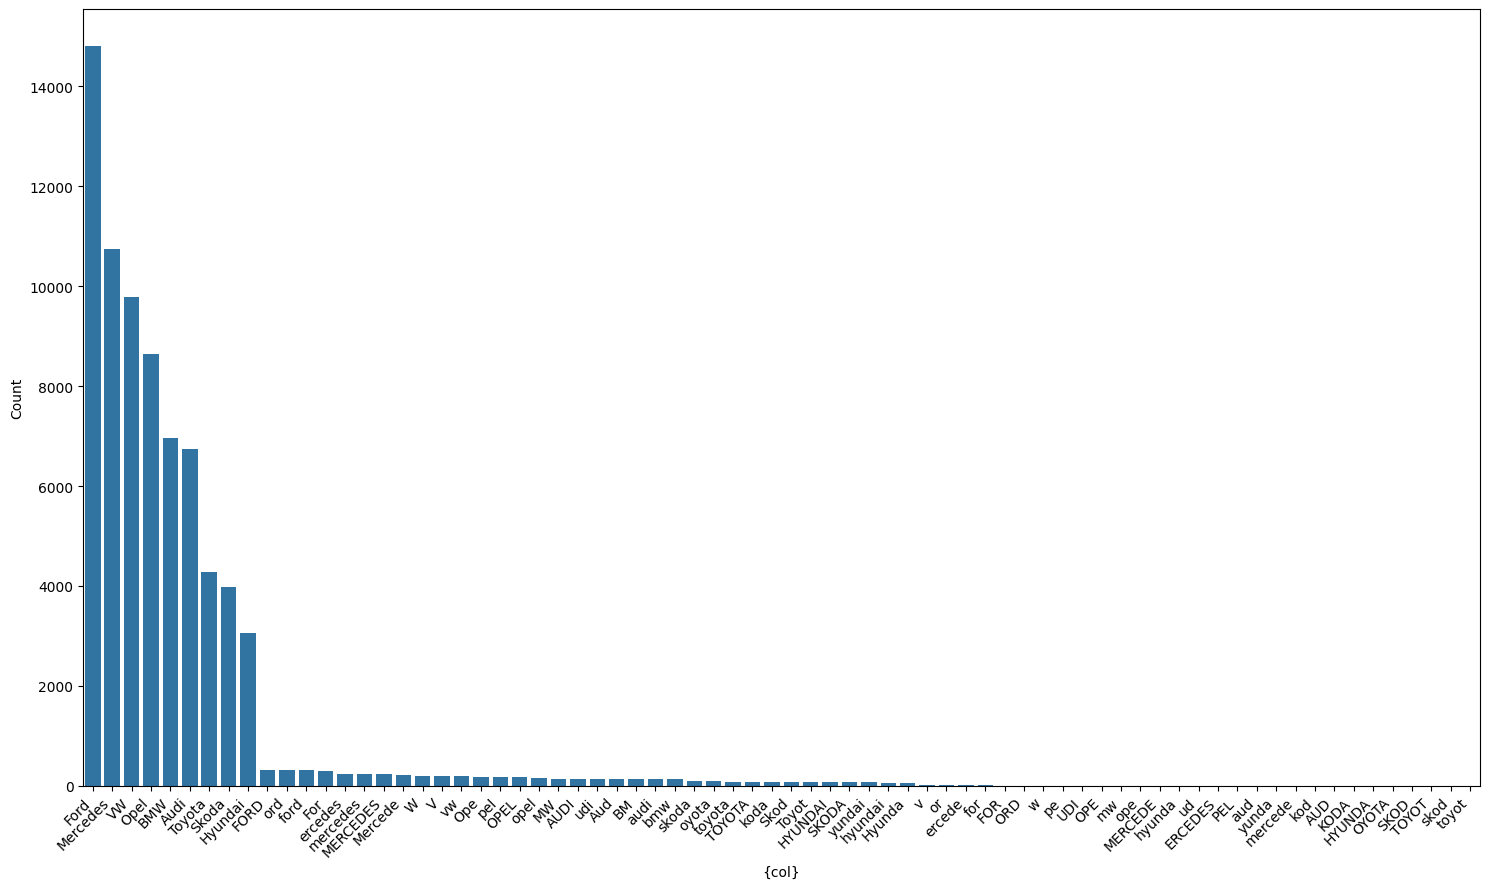

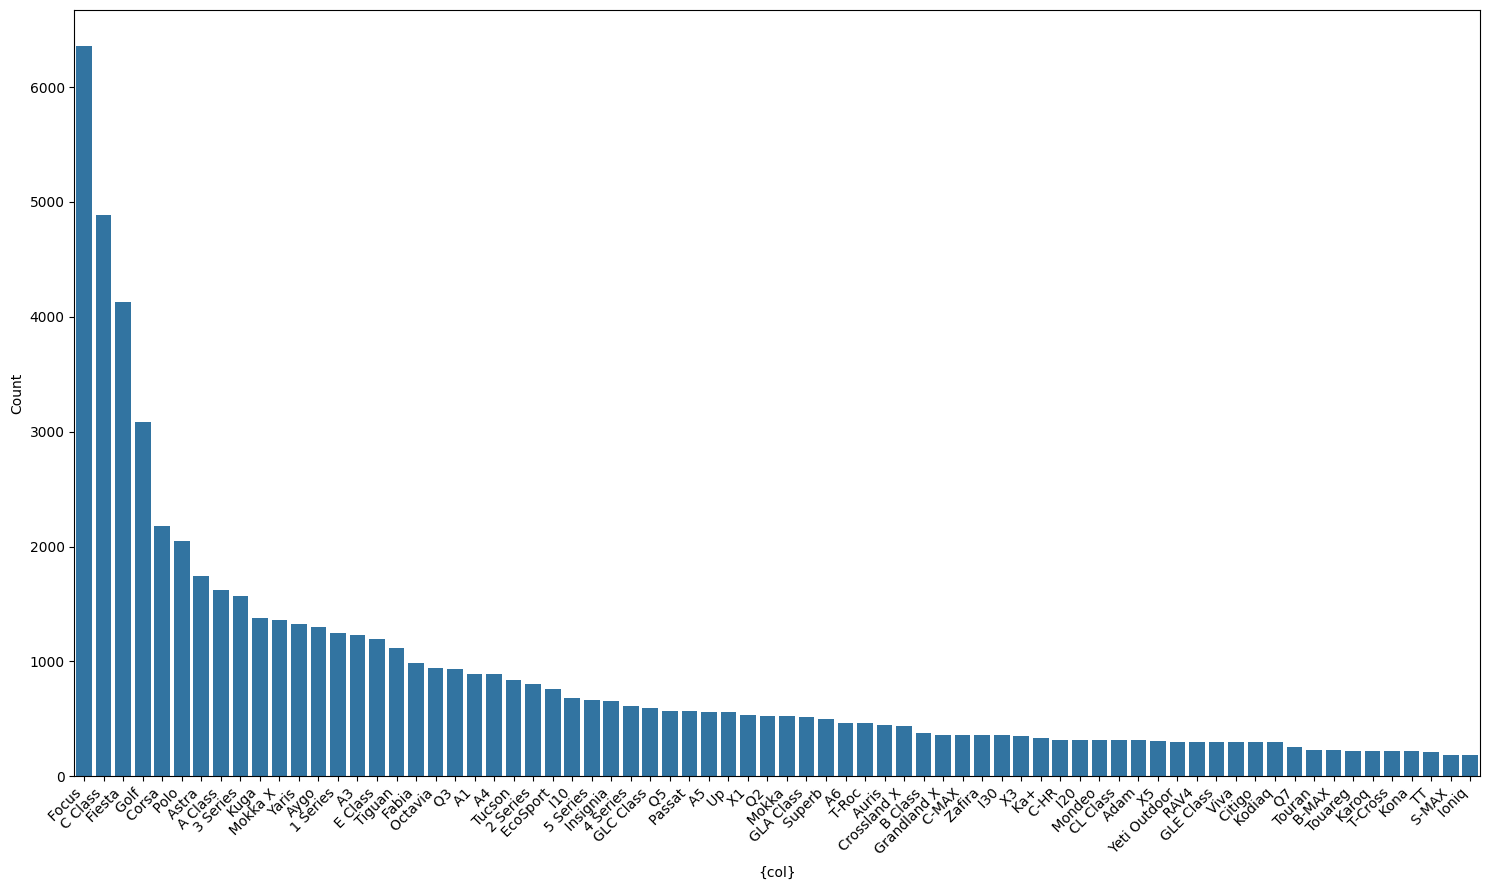

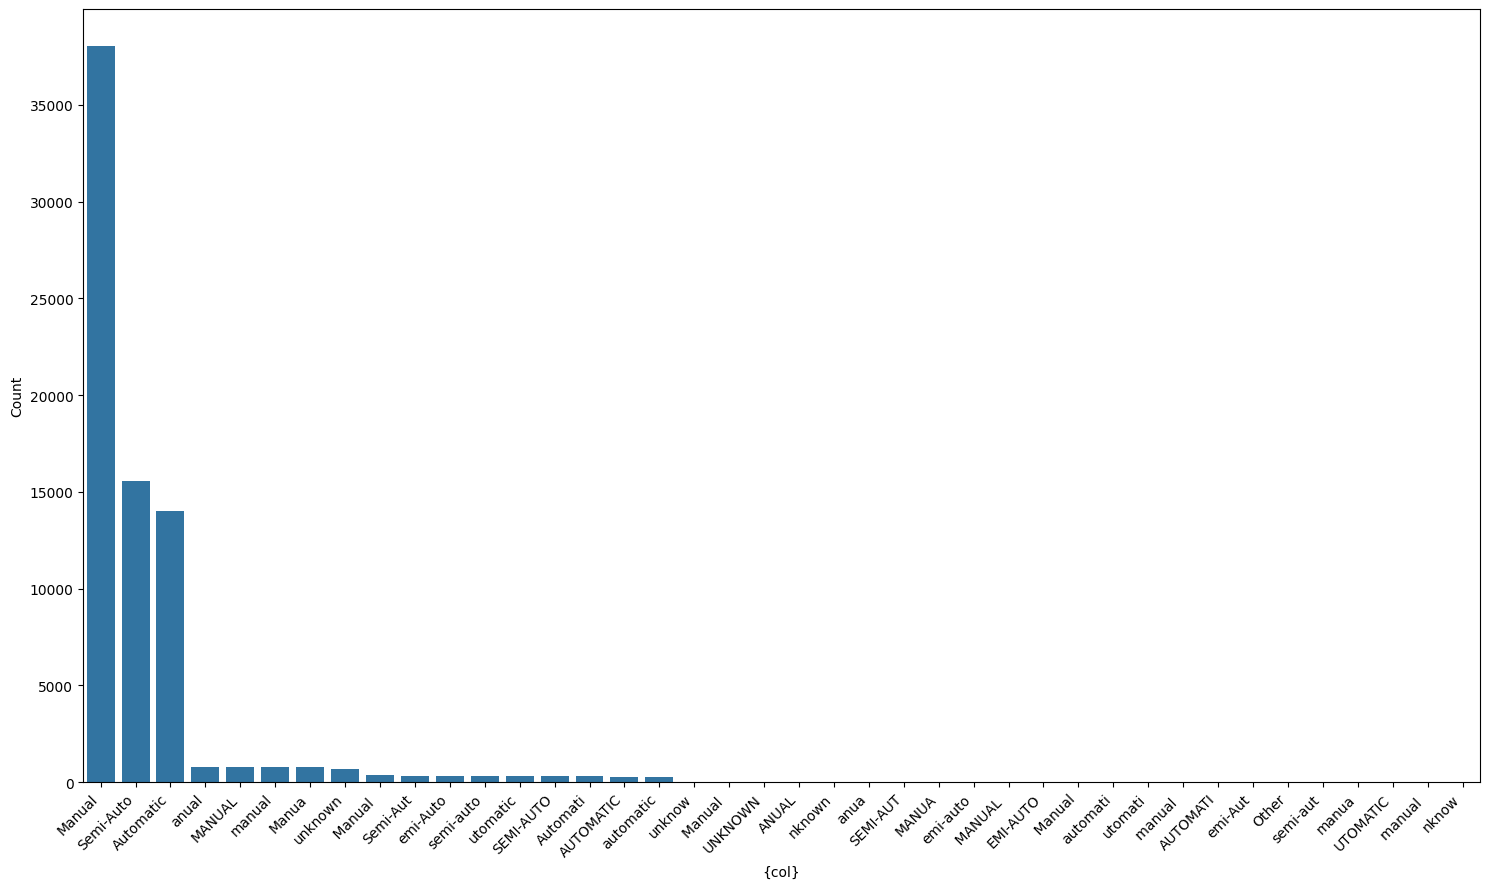

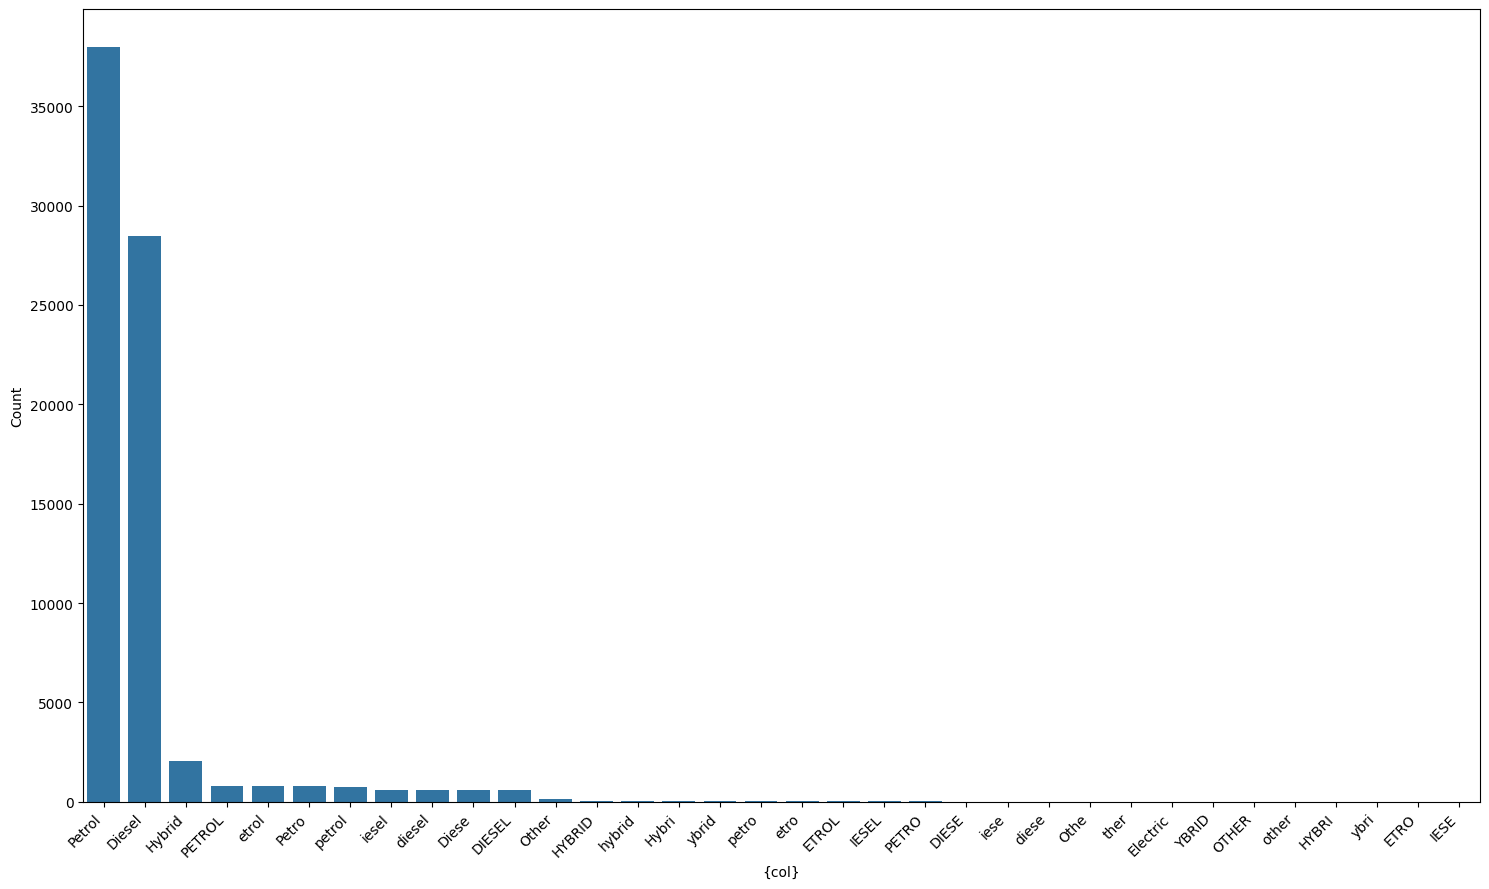

In [17]:
for col in categorical_features:
    top_n = 72
    model_counts = train_df[col].value_counts().nlargest(top_n)

    plt.figure(figsize=(15,9))
    sns.barplot(x=model_counts.index, y=model_counts.values)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("{col}")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [18]:
train_df['model'].value_counts()

model
 Focus        6353
 C Class      4886
 Fiesta       4130
 Golf         3081
 Corsa        2182
              ... 
M5               1
 gls class       1
Mokka            1
 6 Serie         1
 JETTA           1
Name: count, Length: 735, dtype: int64

c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning\Group Project\ml_env\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning\Group Project\ml_env\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning\Group Project\ml_env\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning\Group Project\ml_env\lib\site-packages\pandas\core\arraylike.py:3

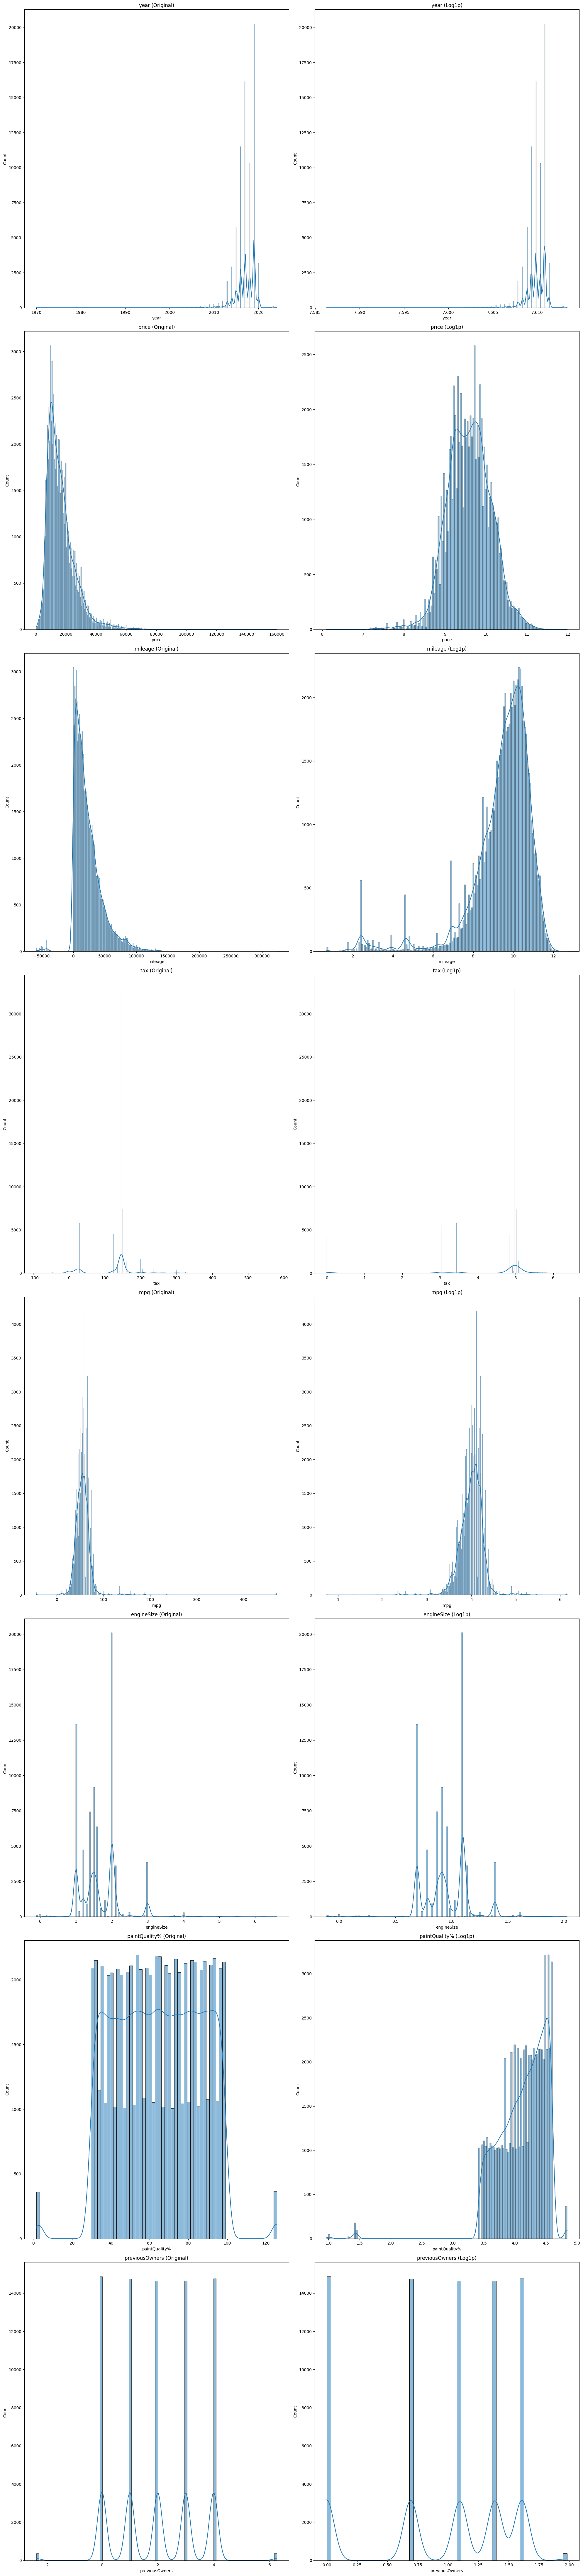

In [19]:
fig, axes = plt.subplots(len(numeric_features), 2, figsize=(20, 11*len(numeric_features)))

for i, col in enumerate(numeric_features):
    sns.histplot(train_df[col].dropna(), kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} (Original)")
    sns.histplot(np.log1p(train_df[col].dropna()), kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f"{col} (Log1p)")

plt.tight_layout()
plt.show()


### Boxplot

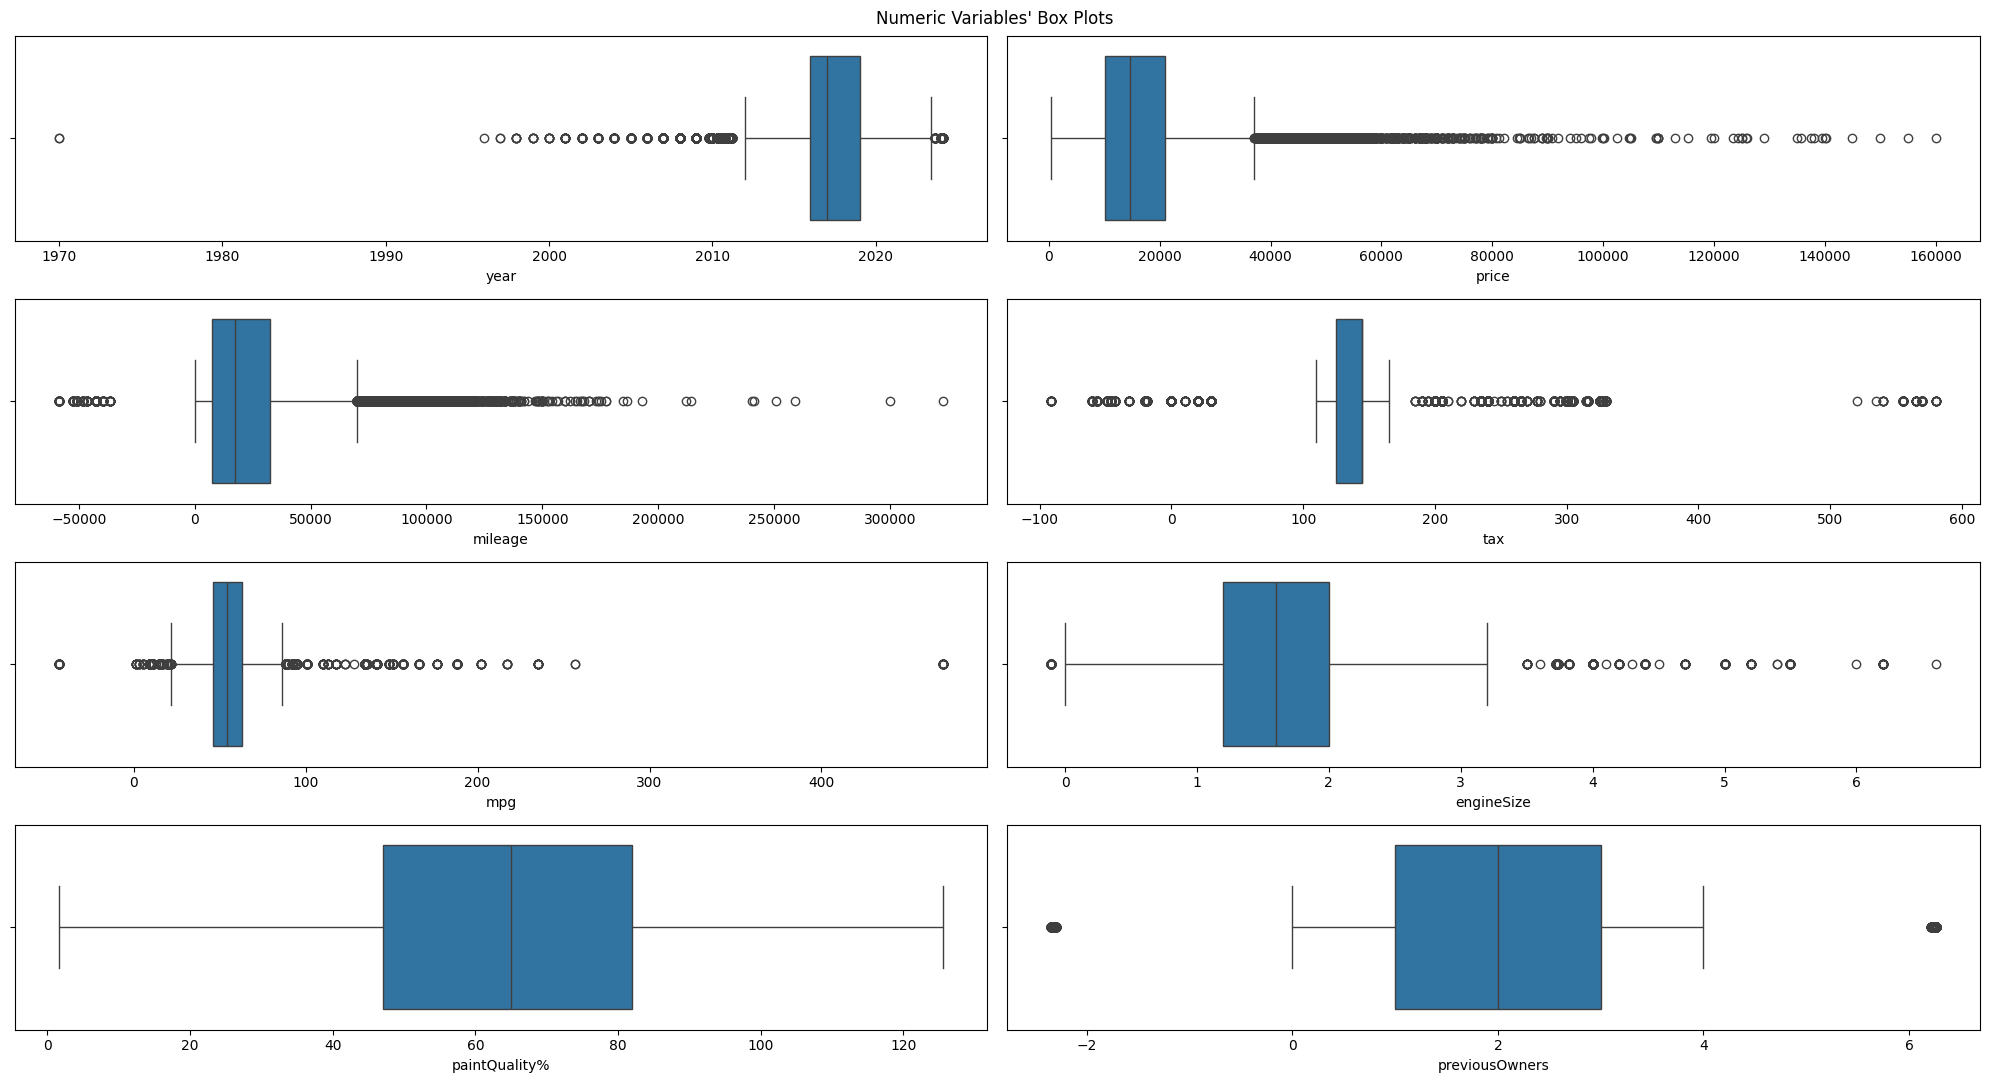

In [20]:
# Define number of subplot rows and columns
sp_rows = 4
sp_cols = ceil(len(numeric_features) / sp_rows)


# Create subplots
fig, axes = plt.subplots(sp_rows, 
                         sp_cols, 
                         figsize=(20, 11),
                         tight_layout=True
                        )

# Plot data
# Iterate across axes objects and associate each histogram (hint: use the ax.hist() instead of plt.hist()):
for ax, feat in zip(axes.flatten(), numeric_features): # Notice the zip() function and flatten() method
    sns.boxplot(x=train_df[feat], ax=ax)
    
# Add a centered title to the figure:
title = "Numeric Variables' Box Plots"

plt.suptitle(title)

plt.show()

### Correlation Analysis

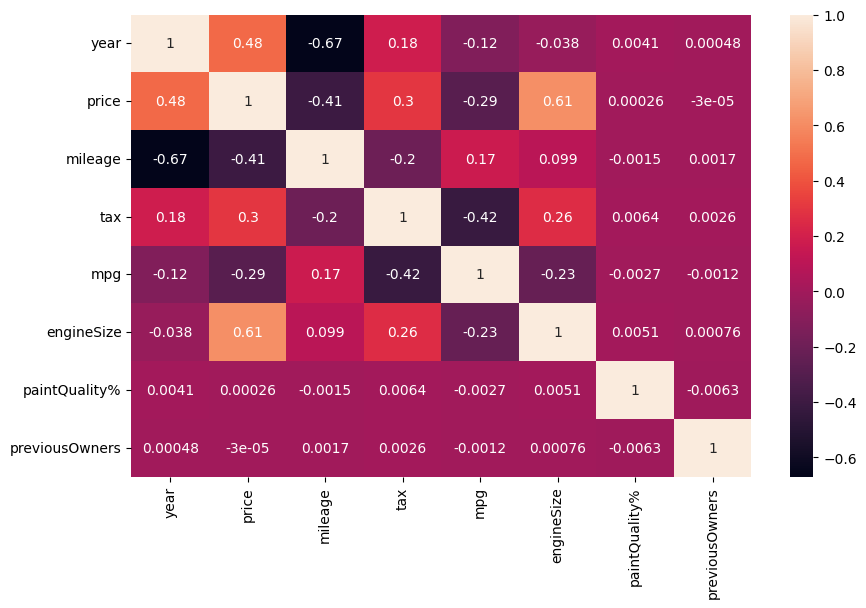

In [21]:
fig = plt.figure(figsize=(10, 6))

# Obtain correlation matrix. 
corr = train_df[numeric_features].corr(method="pearson")

# Plot heatmap of the correlation matrix
sns.heatmap(data=corr, annot=True, )

plt.show()

## Multivariate Analysis

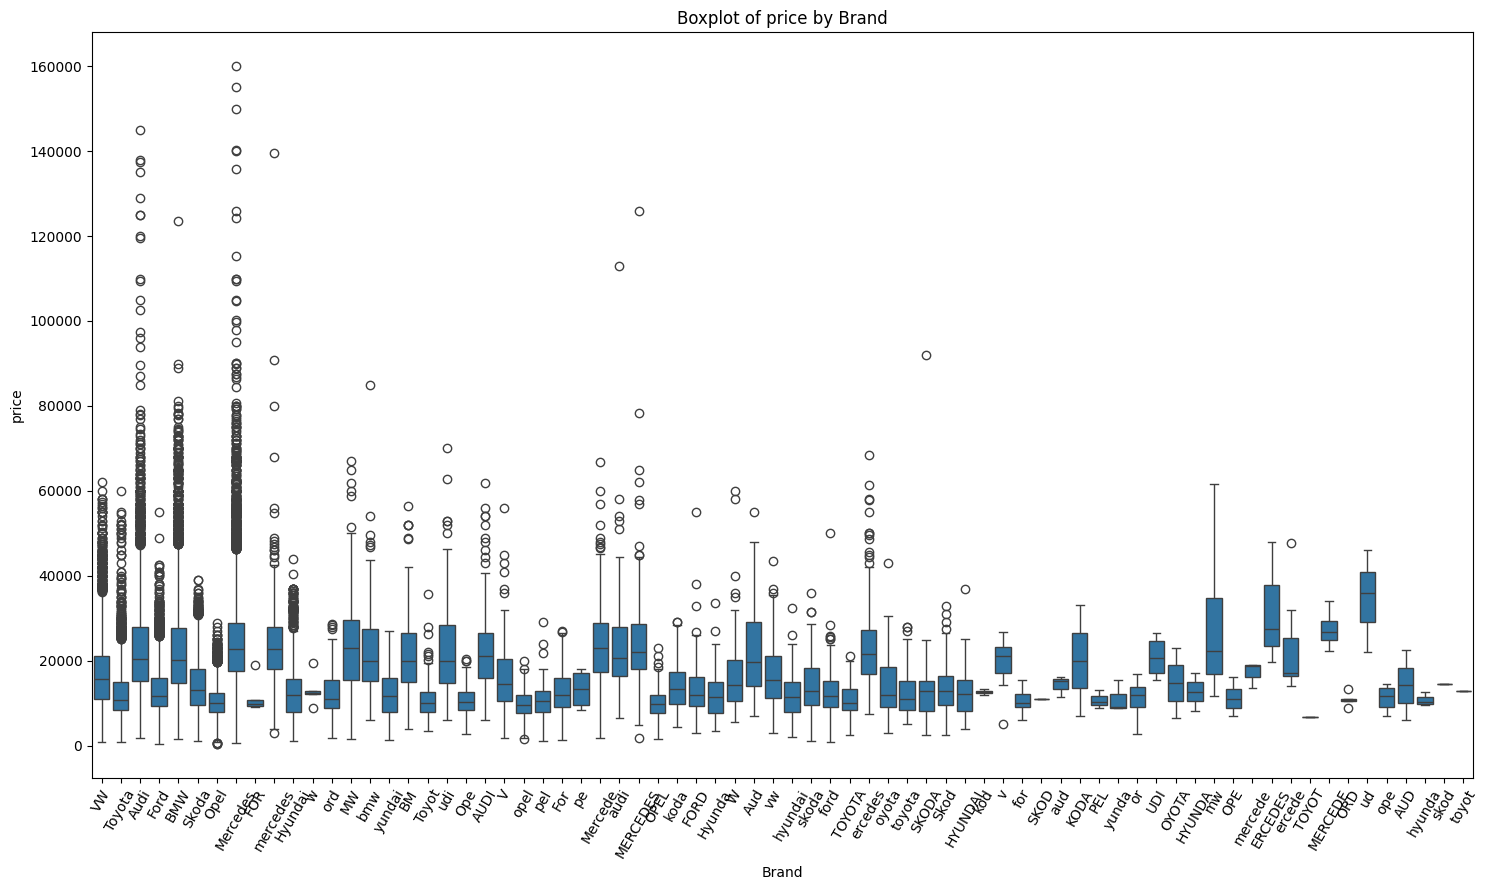

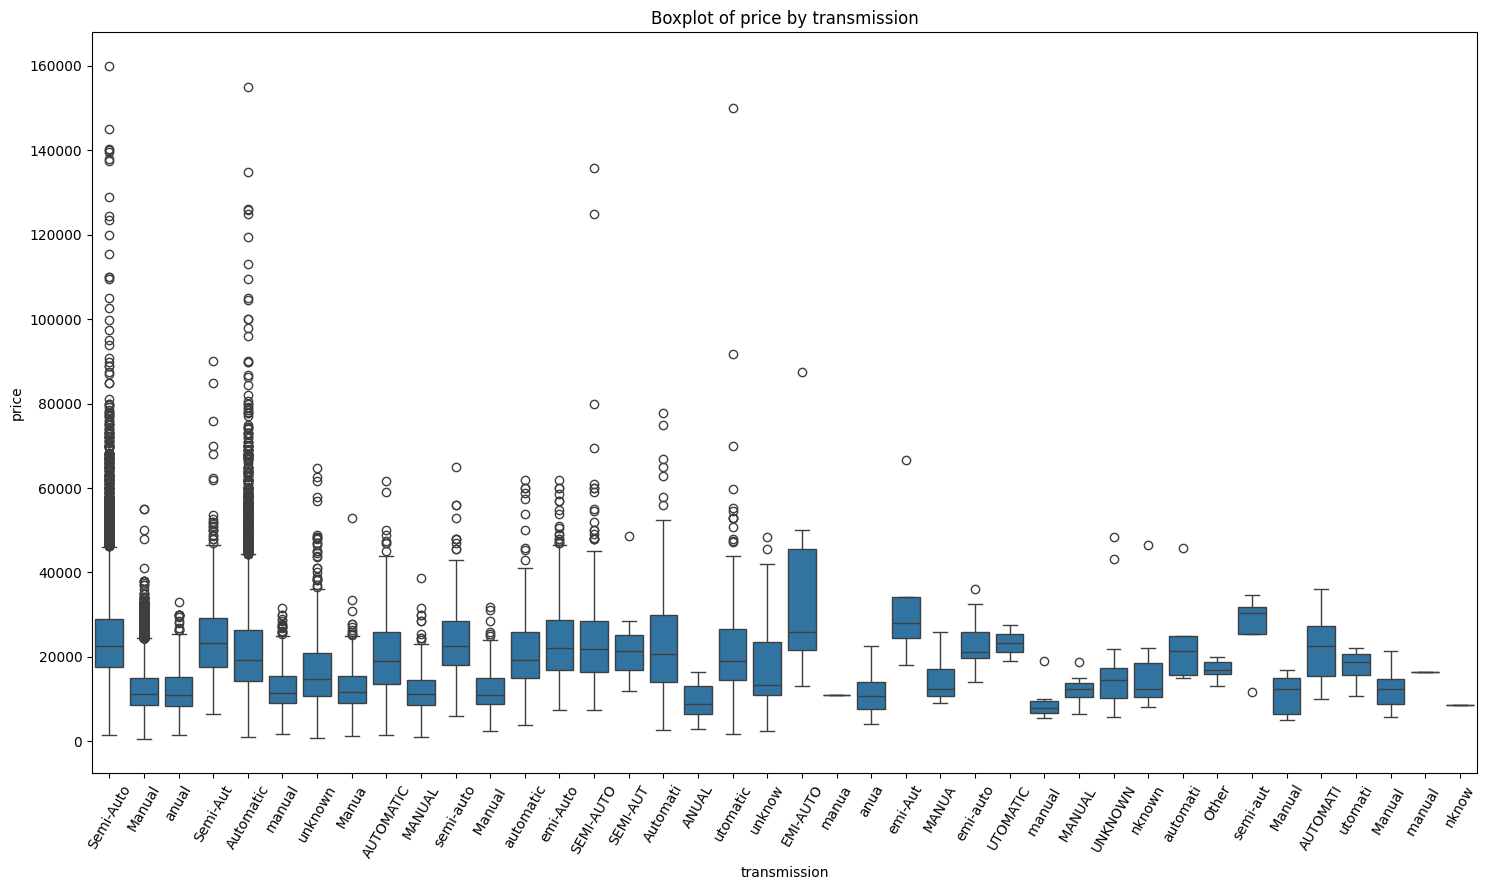

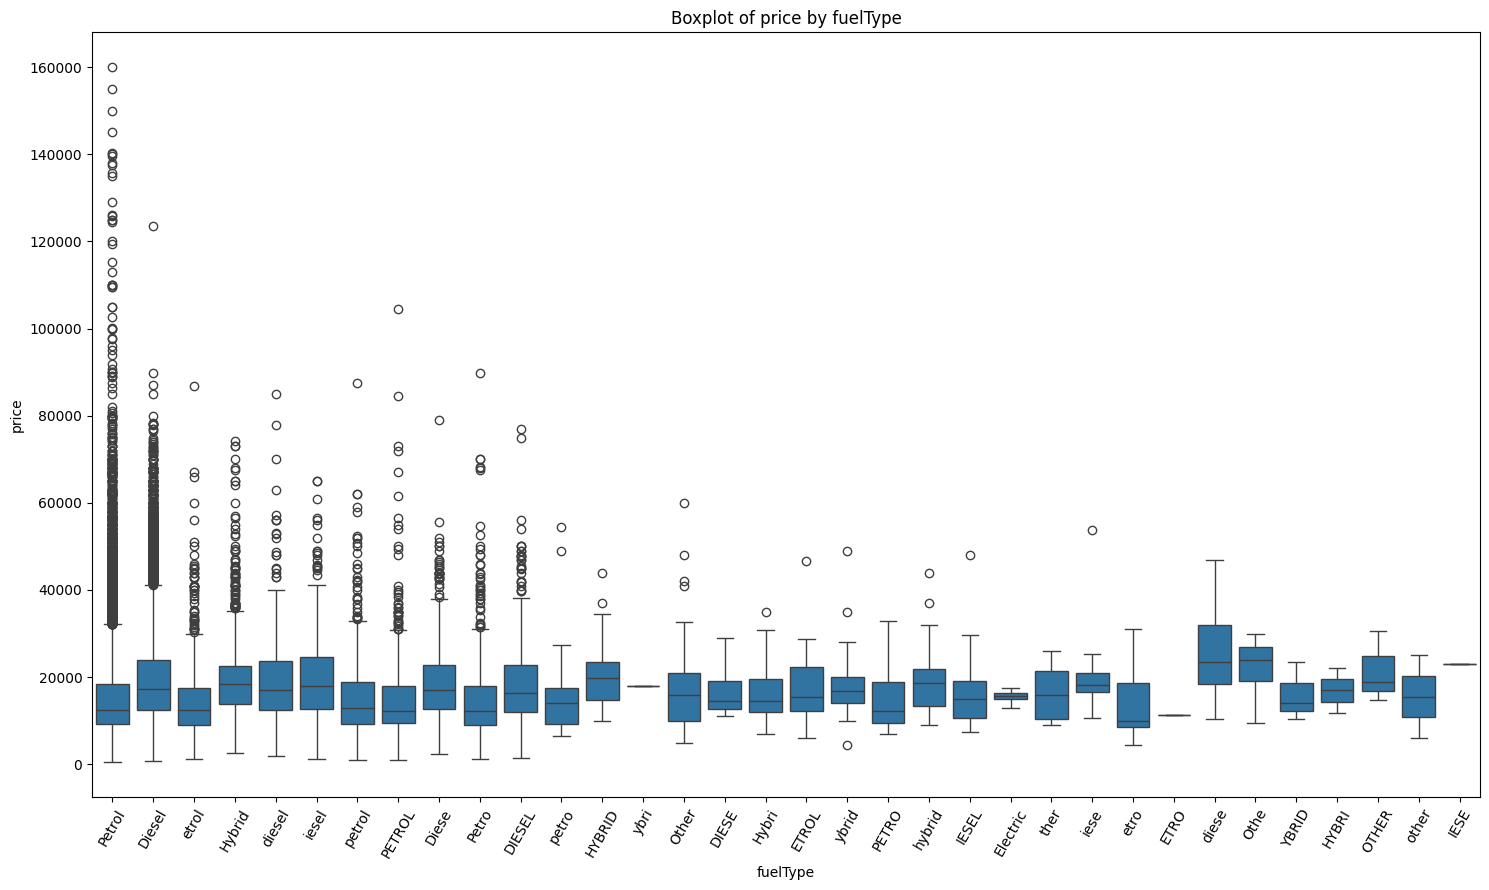

In [22]:
for col in ['Brand', 'transmission', 'fuelType']:
    plt.figure(figsize=(15,9))
    sns.boxplot(data=train_df, x=col, y='price')
    plt.title(f'Boxplot of price by {col}')
    plt.xticks(rotation=60)
    plt.tight_layout()

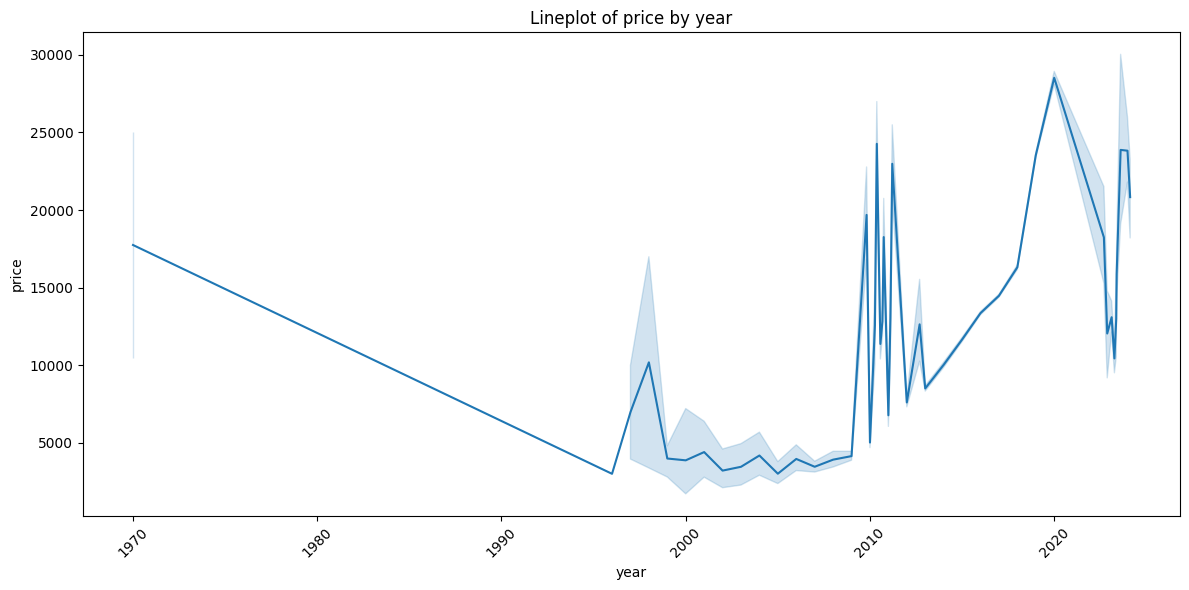

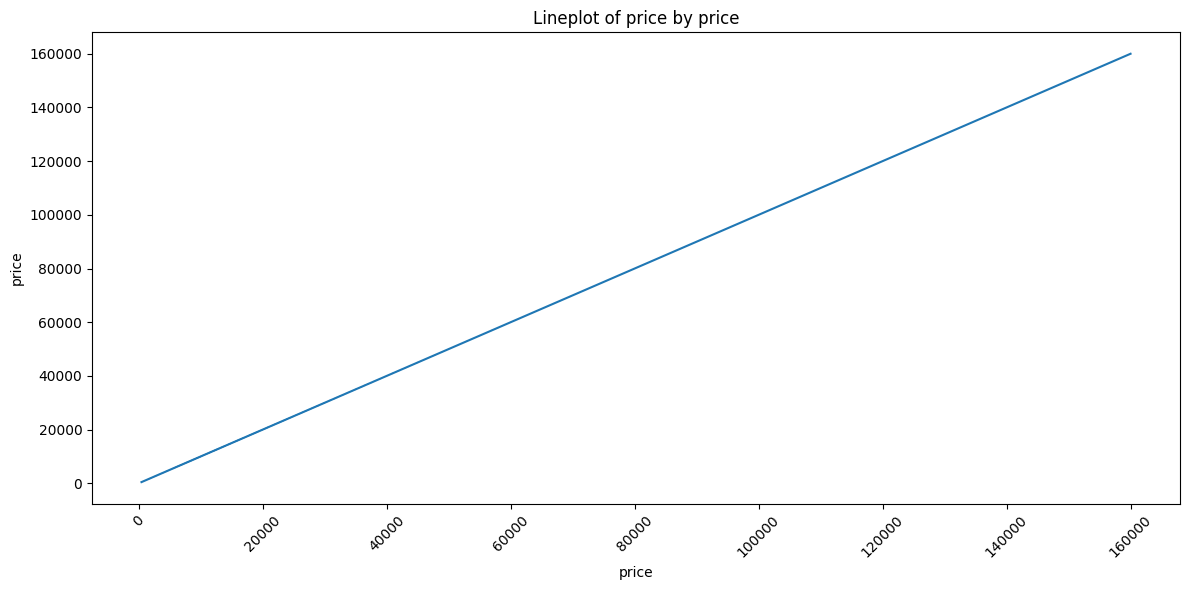

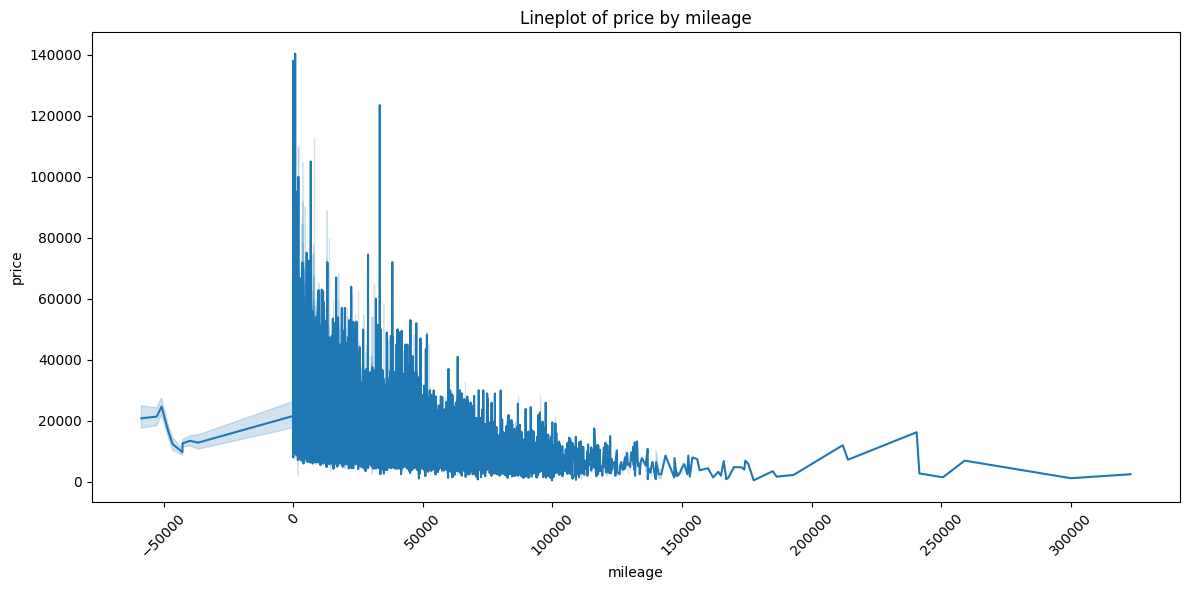

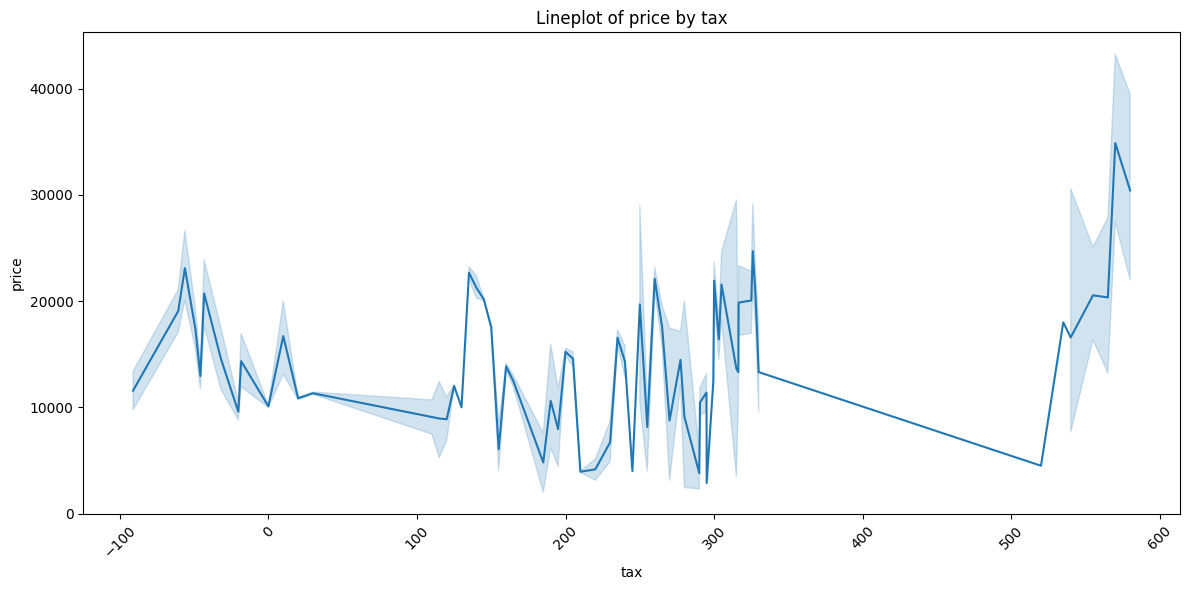

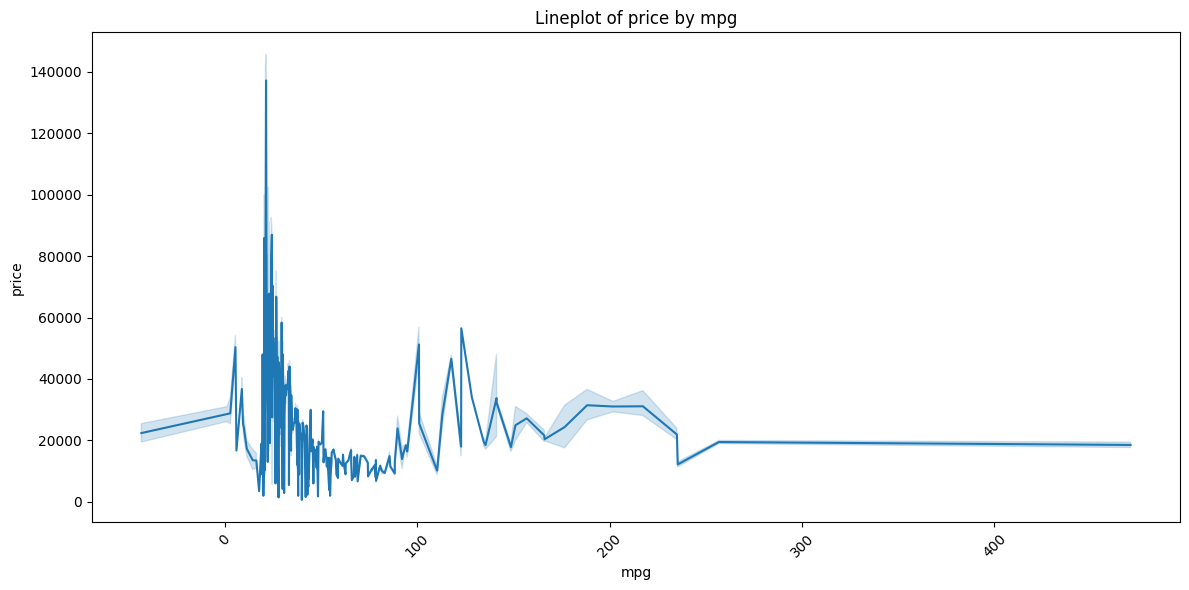

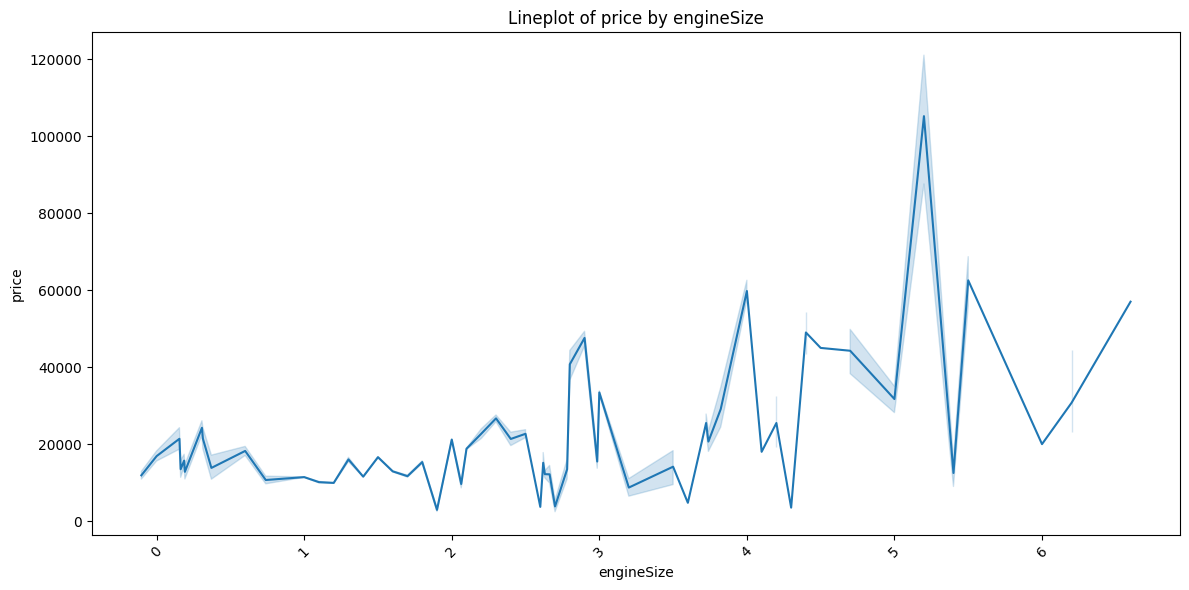

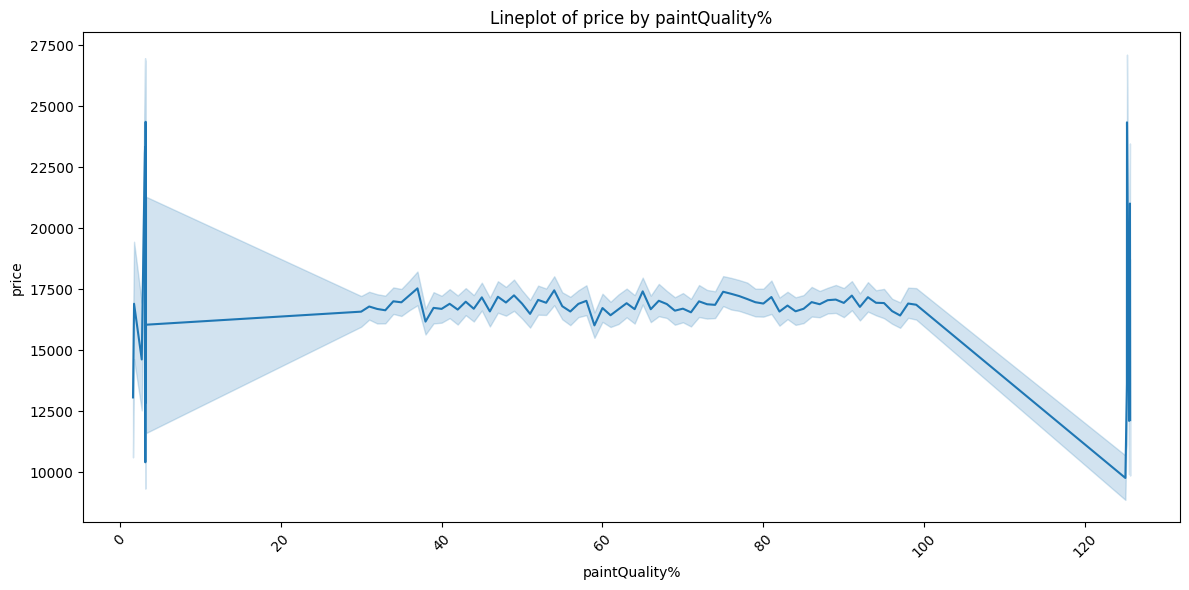

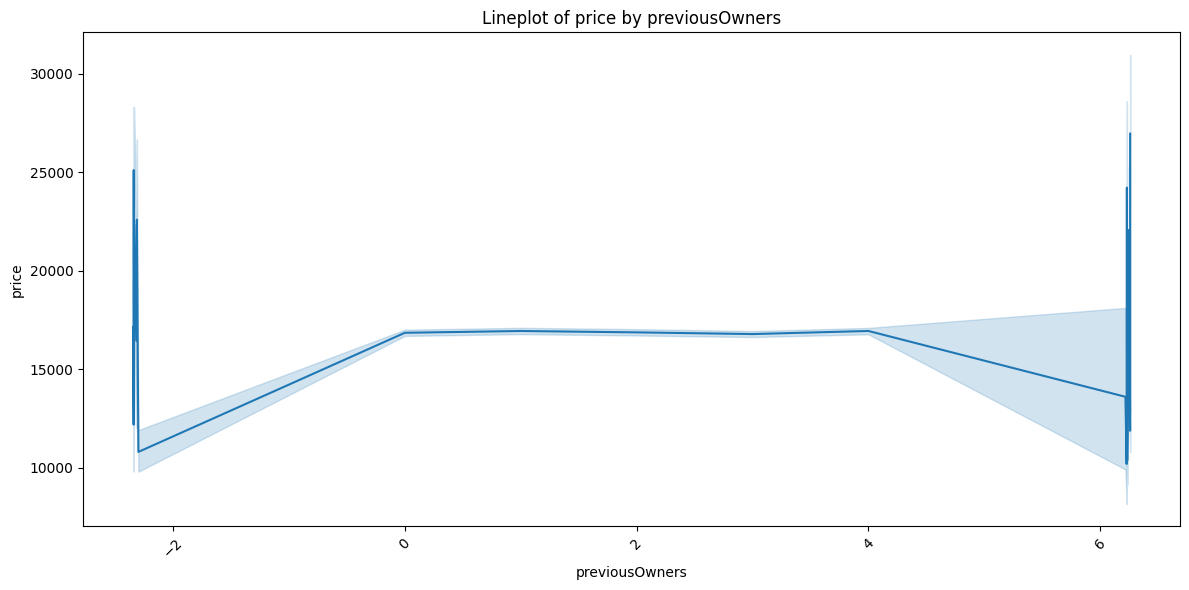

In [23]:
for col in numeric_features:
    plt.figure(figsize=(12,6))
    sns.lineplot(data=train_df, x=col, y='price')
    plt.title(f'Lineplot of price by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()

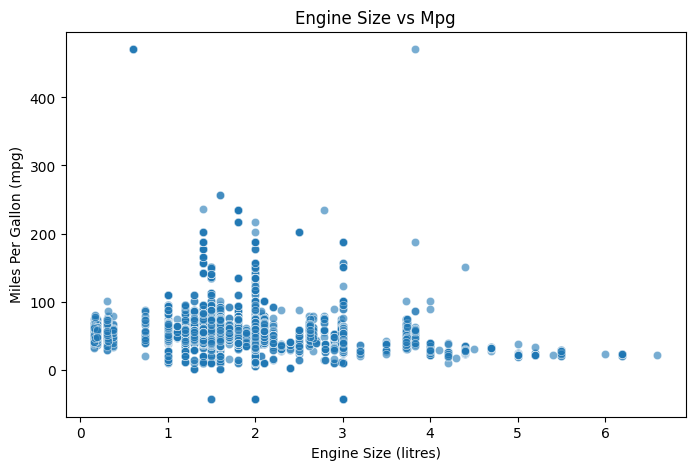

In [24]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=train_df[train_df['engineSize'] > 0], 
    x='engineSize', 
    y='mpg',
    alpha=0.6
)
plt.title('Engine Size vs Mpg')
plt.xlabel('Engine Size (litres)')
plt.ylabel('Miles Per Gallon (mpg)')
plt.show()


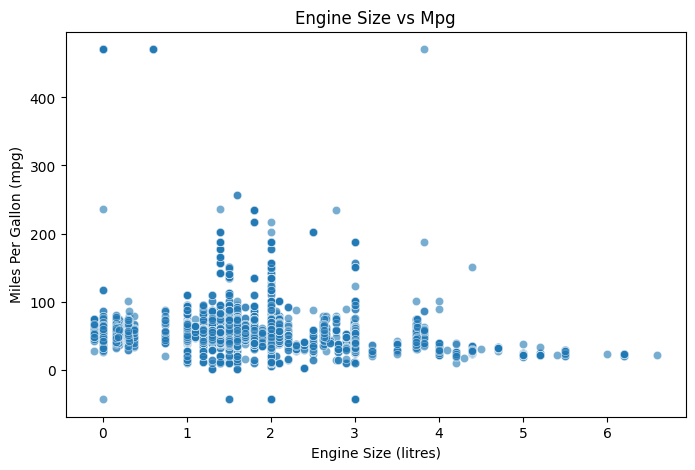

In [25]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=train_df, 
    x='engineSize', 
    y='mpg',
    alpha=0.6
)
plt.title('Engine Size vs Mpg')
plt.xlabel('Engine Size (litres)')
plt.ylabel('Miles Per Gallon (mpg)')
plt.show()

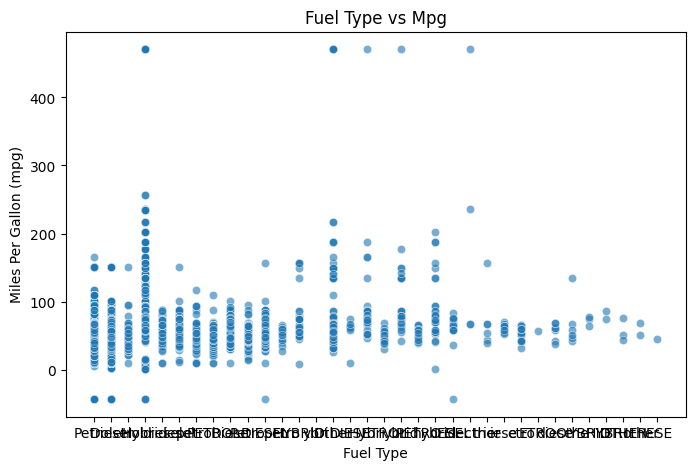

In [26]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=train_df, 
    x='fuelType', 
    y='mpg',
    alpha=0.6
)
plt.title('Fuel Type vs Mpg')
plt.xlabel('Fuel Type')
plt.ylabel('Miles Per Gallon (mpg)')
plt.show()

In-depth exploration

In [27]:
train_df['engineSize'].value_counts()

engineSize
 2.000000    20105
 1.000000    13615
 1.500000     9156
 1.400000     7432
 1.600000     6381
 1.200000     4750
 3.000000     3806
 2.100000     3624
 1.800000     1192
 1.300000      920
 1.700000      618
 1.100000      385
 2.500000      312
 4.000000      295
 2.200000      295
 2.300000      181
 0.000000      180
 2.900000      116
-0.103493       84
 2.631200       80
 0.307074       65
 3.723712       63
 2.985793       52
 0.186425       52
 0.739534       52
 2.064119       51
 4.400000       46
 2.400000       43
 0.154529       39
 3.739235       38
 5.000000       38
 0.313407       35
 5.500000       31
 3.822758       27
 2.800000       26
 2.619641       25
 0.162866       24
 1.900000       23
 0.191462       21
 4.200000       20
 2.781776       19
 3.200000       19
 6.200000       19
 4.700000       18
 0.371127       18
 2.663113       17
 5.200000       17
 3.500000       12
 2.700000        7
 0.600000        4
 5.400000        2
 6.600000        1
 

In [28]:
train_df.query('engineSize == 0.0')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,,
30317,Ford,NaN,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0
21935,Ford,KA,2018.0,8444,Manual,17000.0,Petrol,145.0,57.7,0.0,51.0,0.0
9518,BMW,2 Series,2015.0,14700,Automatic,32882.0,Diesel,125.0,60.1,0.0,55.0,0.0
32528,Hyundai,Tucson,2016.0,13800,Manual,27311.0,Diesel,30.0,61.7,0.0,73.0,1.0
33804,Hyundai,Tucson,2019.0,15000,Manual,22397.0,Petrol,150.0,34.9,0.0,54.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
26630,Ford,Fiesta,2018.0,11463,NaN,18000.0,Petro,145.0,65.7,0.0,82.0,0.0
20128,Ford,Focus,2018.0,18389,Manual,19000.0,Petrol,NaN,NaN,0.0,48.0,2.0
47605,Skoda,Fabia,2018.0,11500,Manual,10720.0,Petrol,150.0,64.2,0.0,84.0,4.0


In [29]:
train_df.query('engineSize == 0').groupby(['Brand', 'model'])['engineSize'].count()

Brand   model 
Audi    A1        1
        A3        3
        A4        1
        A5        1
        Q2        3
                 ..
VW      T-Roc     2
        Tiguan    2
bmw     i3        2
hyunda  I10       1
ord     Mondeo    1
Name: engineSize, Length: 62, dtype: int64

In [30]:
train_df.query('engineSize >= 6')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,,
38980,Mercedes,C Class,2013.0,23000,Semi-Auto,43442.000000,Petrol,NaN,NaN,6.2,76.0,0.0
46372,Mercedes,C Class,2013.0,22995,Semi-Auto,49964.000000,Petrol,NaN,23.0,6.2,78.0,3.0
9197,BMW,7 Series,2017.0,57000,Automatic,11297.000000,Petrol,145.000000,22.1,6.6,68.0,1.0
42286,Mercedes,C Class,2014.0,26998,Semi-Auto,24175.000000,Petrol,NaN,NaN,6.2,93.0,2.0
39900,Mercedes,C Class,2014.0,28990,Semi-Auto,19562.000000,Petrol,-56.193202,NaN,6.2,83.0,0.0
39852,ercedes,S Class,2010.0,26990,Automatic,38000.000000,Petrol,570.000000,19.5,6.2,76.0,4.0
35612,Mercedes,C Class,2013.0,23990,Automatic,NaN,Petrol,570.000000,23.5,6.2,44.0,2.0
36196,Mercedes,C Clas,2014.0,25885,Semi-Auto,86705.854885,Petrol,NaN,NaN,6.2,31.0,0.0
35538,NaN,C Class,NaN,22995,Semi-Auto,49964.000000,Petrol,326.028233,NaN,6.2,58.0,3.0


In [31]:
train_df.query('year < 2010')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,,
35220,Mercedes,SLK,2003.000000,3650,Automatic,58500.0,Petrol,325.0,30.0,2.3,45.0,4.0
56599,Opel,Astra,2009.000000,1950,Automatic,112000.0,Petrol,305.0,36.2,1.8,71.0,2.0
34317,Hyundai,Getz,2007.000000,1995,unknown,57000.0,Petrol,125.0,51.4,1.1,45.0,4.0
44251,Mercedes,C Class,2005.000000,2495,Automatic,110461.0,Diesel,NaN,NaN,2.1,57.0,1.0
56163,Opel,Corsa,2004.000000,2444,Manual,NaN,Petrol,NaN,53.3,1.0,69.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
12161,BMW,2 Series,2009.816757,13700,Automatic,52541.0,Diesel,125.0,57.6,2.0,46.0,0.0
1150,Audi,RS4,2006.000000,17999,anual,66000.0,Petrol,535.0,20.3,4.2,84.0,1.0
18141,Ford,C-MAX,2008.000000,1999,Manual,97000.0,Petrol,235.0,39.8,1.8,98.0,4.0


In [32]:
train_df.query('mileage <= 0')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,,
70615,VW,Tiguan,2020.0,25000,Manual,-48190.655673,Petrol,145.0,38.2,1.5,89.0,3.0
43529,Mercedes,C Class,2019.0,25780,Semi-Auto,-50755.210230,Diesel,NaN,NaN,2.0,72.0,3.0
71090,VW,Golf,2018.0,14995,Manual,-48190.655673,Diesel,150.0,57.7,1.6,83.0,2.0
7845,BMW,3 Series,2019.0,23498,Semi-Auto,-58540.574478,Diesel,145.0,54.3,2.0,38.0,NaN
24999,Ford,FIESTA,2017.0,8895,Manual,-42650.453719,Petrol,125.0,54.3,1.2,45.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
56373,Opel,NaN,2018.0,8514,Manual,-42707.564215,Petrol,150.0,55.4,1.4,49.0,1.0
45765,Mercedes,GLE Class,2020.0,54995,Automatic,-50755.210230,Diesel,150.0,32.8,3.0,69.0,4.0
38413,Mercedes,SLK,2015.0,17900,Automati,-50755.210230,Diesel,150.0,56.5,2.1,40.0,3.0


In [33]:
train_df.query('mileage > 50000')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,,
14704,BMW,3 Series,2014.0,8199,anual,101153.348285,Diesel,30.0,65.7,2.0,74.0,0.0
50783,Skoda,Octavia,2017.0,7500,Manual,116750.000000,Diesel,145.0,68.9,1.6,59.0,4.0
34015,Hyundai,I30,2016.0,7500,manual,51236.000000,Diesel,20.0,72.4,1.6,94.0,4.0
68197,w,Golf,2013.0,12299,Automatic,64739.000000,Petrol,160.0,44.1,2.0,47.0,4.0
55065,Toyota,C-HR,2017.0,15490,Automatic,59000.000000,Hybrid,0.0,74.3,1.8,95.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
45758,Mercedes,CL Class,2015.0,17491,Semi-Auto,54943.000000,Diesel,20.0,62.8,2.1,74.0,3.0
66803,VW,Polo,2017.0,9895,Manual,50899.000000,Petrol,150.0,60.1,1.2,65.0,3.0
35773,Mercedes,C Class,2015.0,13790,NaN,54000.000000,Petrol,125.0,52.3,2.0,48.0,1.0


In [34]:
train_df.query('tax == 0')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,,
55065,Toyota,C-HR,2017.0,15490,Automatic,59000.0,Hybrid,0.0,74.3,1.8,95.0,2.0
64396,Opel,Astra,2015.0,6995,NaN,NaN,Diesel,0.0,78.5,1.6,61.0,2.0
54783,Toyota,Yaris,2014.0,10490,Automatic,34528.0,Hybrid,0.0,80.7,1.5,79.0,1.0
47148,Skoda,Rapid,2016.0,7991,Manual,33395.0,iesel,0.0,67.3,1.6,NaN,3.0
19051,Ford,Fiesta,2013.0,6500,Manual,43181.0,Petrol,0.0,65.7,1.0,88.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
54268,Toyota,Aygo,2017.0,6620,Manual,10266.0,Petrol,0.0,69.0,1.0,51.0,0.0
52992,Toyota,Aygo,2016.0,8550,Manual,20680.0,Petrol,0.0,69.0,1.0,66.0,2.0
30535,For,Fiesta,2016.0,8990,Manual,46000.0,NaN,0.0,65.7,1.0,88.0,2.0


In [35]:
train_df.query('tax < 0')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,,
35263,Mercedes,C Clas,NaN,11295,Automatic,45000.0,Petrol,-56.193202,46.3,1.6000,59.0,NaN
46204,Mercedes,C Class,2019.0,66699,Semi-Auto,630.0,Petrol,-56.193202,28.5,4.0000,32.0,2.0
24750,Ford,Fiesta,2019.0,17000,Manual,796.0,Petrol,-45.780610,58.9,1.0000,80.0,4.0
20350,Ford,Focus,2015.0,7260,Manual,60661.0,Petrol,-45.780610,60.1,1.0000,NaN,2.0
64978,Opel,Astra,2016.0,9595,Automatic,30765.0,Petrol,-20.241079,50.4,1.4000,30.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
11302,BMW,4 Series,2018.0,21470,Automatic,40553.0,Petrol,-43.242082,41.5,3.0000,44.0,3.0
44238,Mercedes,SLK,2001.0,4990,Automatic,64476.0,Petrol,-56.193202,27.2,3.2000,47.0,3.0
20309,Ford,Fiesta,2013.0,6000,Manual,48133.0,Petrol,-45.780610,54.3,2.6312,40.0,4.0


In [36]:
train_df.query('mpg < 0')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,,
13396,BMW,X1,2019.0,25480,Semi-Auto,5163.000000,Petrol,145.000000,-43.421768,2.0,86.0,1.0
14934,BMW,3 Series,2019.0,29500,Automatic,3185.000000,Petrol,145.000000,-43.421768,2.0,97.0,3.0
14127,BMW,2 Series,2020.0,32450,Semi-Auto,1118.000000,Diesel,145.000000,-43.421768,2.0,37.0,1.0
14420,BMW,2 Series,2015.0,17799,Automatic,38902.000000,Petrol,260.000000,-43.421768,3.0,33.0,4.0
12400,BMW,X5,2016.0,26995,Automatic,46126.000000,Diesel,200.000000,-43.421768,3.0,77.0,2.0
14603,BMW,2 Series,2015.0,17541,Semi-Auto,26035.000000,Petrol,165.000000,-43.421768,2.0,75.0,3.0
11181,BMW,1 Series,2019.0,19298,Semi-Auto,10040.000000,Diesel,145.000000,-43.421768,2.0,70.0,3.0
7781,BMW,3 Series,2017.0,14800,Manual,29968.000000,DIESEL,30.000000,-43.421768,2.0,52.0,1.0
9202,BMW,X1,2016.0,17000,Automatic,46968.000000,Diesel,125.000000,-43.421768,2.0,82.0,0.0


In [37]:
train_df.query('mpg <= 30').groupby(['fuelType'])['mpg'].count()

fuelType
DIESE       1
DIESEL      4
Diese       2
Diesel    214
HYBRID      1
Hybrid     27
IESEL       1
Other       1
PETROL     16
Petro      14
Petrol    724
diesel      4
etrol      16
hybrid      1
iesel       3
petro       1
petrol     16
Name: mpg, dtype: int64

In [38]:
train_df.query('mpg >= 200').groupby(['fuelType'])['mpg'].count()

fuelType
Electric     2
Hybri        1
Hybrid      39
Other        6
hybrid       1
ybrid        1
Name: mpg, dtype: int64

In [39]:
train_df['previousOwners'].value_counts()

previousOwners
 0.000000    14879
 4.000000    14763
 1.000000    14754
 3.000000    14649
 2.000000    14644
-2.340306       84
 6.258231       78
 6.245835       64
-2.345650       58
-2.339360       58
 6.258371       50
 6.233082       46
-2.299439       43
 6.230180       37
-2.335123       37
-2.312260       34
 6.248251       32
-2.337445       25
 6.217724       21
 6.241779       20
-2.340102       17
 6.227898       15
-2.317331       15
Name: count, dtype: int64

In [40]:
train_df['fuelType'].value_counts()

fuelType
Petrol      37995
Diesel      28474
Hybrid       2043
PETROL        795
etrol         794
Petro         785
petrol        746
iesel         603
diesel        599
Diese         582
DIESEL        582
Other         150
HYBRID         50
hybrid         46
Hybri          43
ybrid          37
petro          18
etro           17
ETROL          16
IESEL          16
PETRO          14
DIESE          10
iese           10
diese           8
Othe            6
ther            6
Electric        4
YBRID           3
OTHER           3
other           2
HYBRI           2
ybri            1
ETRO            1
IESE            1
Name: count, dtype: int64

# Data Pre-processing

In [41]:
train_df.isna().sum()

Brand             1521
model             1517
year              1491
price                0
transmission      1522
mileage           1463
fuelType          1511
tax               7904
mpg               7926
engineSize        1516
paintQuality%     1524
previousOwners    1550
dtype: int64

### Numerical Variables

Some column have negative values that couldn't be logically explain (ex: a car couldn't have negative mileage, the minimum posible would be a brand new car with 0 miles.) We decided to maintain the absolute value, treating the referred negative as typo.

In [42]:
def negative_values(df, column):
   df[column] = np.where(df[column] < 0, -df[column], df[column])

In [43]:
negative_values(train_df, 'mileage')
negative_values(train_df, 'tax')
negative_values(train_df, 'mpg')
negative_values(train_df, 'engineSize')
negative_values(train_df, 'previousOwners')

In [44]:
negative_values(test_df, 'mileage')
negative_values(test_df, 'tax')
negative_values(test_df, 'mpg')
negative_values(test_df, 'engineSize')
negative_values(test_df, 'previousOwners')

Cap the percentages at 100% as having paint quality with values above 100% would be non-sensical because 100% means that the paint is in perfect conditions

In [45]:
def percentage_cap(df, column):
    df[column] = np.where(df[column] > 100, 100, df[column])

In [46]:
percentage_cap(train_df, 'paintQuality%')
percentage_cap(test_df, 'paintQuality%')

In [47]:
float_cols = train_df.select_dtypes(include='float')
train_df[float_cols.columns] = float_cols.round(1)

In [48]:
train_df.describe()

,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners
count,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.00000,74423.000000
mean,2017.096656,16881.889553,23470.107521,120.842691,55.198486,1.660340,64.46612,2.017625
std,2.208735,9736.926322,21635.013136,64.568837,16.343515,0.572556,20.73427,1.440802
min,1970.000000,450.000000,1.000000,0.000000,1.100000,0.000000,1.60000,0.000000
25%,2016.000000,10200.000000,7612.000000,125.000000,46.300000,1.200000,47.00000,1.000000
50%,2017.000000,14699.000000,17530.000000,145.000000,54.300000,1.600000,65.00000,2.000000
75%,2019.000000,20950.000000,32831.500000,145.000000,62.800000,2.000000,82.00000,3.000000
max,2024.100000,159999.000000,323000.000000,580.000000,470.800000,6.600000,100.00000,6.300000


### Categorical Variables

In [49]:
def preprocess_categoric(df,column):
    df[column] = (
        df[column]
        .str.strip()      # remove leading/trailing spaces
        .str.lower()      # make everything lowercase
    )

In [50]:
preprocess_categoric(train_df,'transmission')
preprocess_categoric(test_df,'transmission')

In [51]:
preprocess_categoric(train_df,'fuelType')
preprocess_categoric(test_df,'fuelType')

In [52]:
preprocess_categoric(train_df,'Brand')
preprocess_categoric(test_df,'Brand')

In [53]:
preprocess_categoric(train_df,'model')
preprocess_categoric(test_df,'model')

In [54]:
def preprocess_transmission(df):
    df['transmission'] = df['transmission'].replace({
        'anual': 'manual', 'manua': 'manual', 'anua': 'manual',
        'utomatic': 'automatic', 'utomati': 'automatic', 'automati': 'automatic',
        'semi-aut': 'semi-auto', 'emi-auto': 'semi-auto', 'emi-aut': 'semi-auto',
        'unknow': 'unknown', 'nknown': 'unknown', 'nknow': 'unknown'
    })

In [55]:
preprocess_transmission(train_df)
preprocess_transmission(test_df)

In [56]:
def preprocess_fuelType(df):
    df['fuelType'] = df['fuelType'].replace({
        'petro': 'petrol', 'etrol': 'petrol', 'etro': 'petrol',
        'iesel': 'diesel', 'diese': 'diesel', 'iese': 'diesel',
        'hybri': 'hybrid', 'ybrid': 'hybrid', 'ybri': 'hybrid',
        'othe': 'other', 'ther': 'other',
    })

In [57]:
preprocess_fuelType(train_df)
preprocess_fuelType(test_df)

In [58]:
def preprocess_Brand(df):
    df['Brand'] = df['Brand'].replace({
        'ord': 'ford', 'for': 'ford', 'or': 'ford',
        'ercedes': 'mercedes', 'mercede': 'mercedes', 'ercede': 'mercedes',
        'skod': 'skoda', 'koda': 'skoda', 'kod': 'skoda',
        'oyota': 'toyota', 'toyot': 'toyota',
        'udi': 'audi', 'aud': 'audi', 'ud': 'audi',
        'ope': 'opel', 'pel': 'opel', 'pe': 'opel',
        'yundai': 'hyundai', 'hyunda': 'hyundai', 'yunda': 'hyundai',
        'bm': 'bmw', 'mw': 'bmw', 
        'v': 'vw', 'w': 'vw',
    })

In [59]:
preprocess_Brand(train_df)
preprocess_Brand(test_df)

In [60]:
train_df['model'].value_counts()

model
focus           6775
c class         5194
fiesta          4384
golf            3261
corsa           2319
                ... 
urban cruise       1
6 serie            1
land cruise        1
vers               1
terracan           1
Name: count, Length: 296, dtype: int64

There are 735 models in the dataset but after inspection there are several repeated models due to capitalization and spelling mistakes. We manually corrected the spelling and had all instances lower cased. After this a few models remained as the designation was not complete (audi a, audi q, audi rs, bmw x, bmw m, bmw z, bmw i). For all these cases, the letter represents a series of models (ex: there is bmw m1, bmw m2, bmw m3, etc) so we will add the instance to one of the models. For bmw m, bmw z, bmw i there were few instances and a dominant model so we attributed it to the most frequent model. For the other situations, there were several models with considerable representation so we opted to attribute instances based on model distribution. There were a few instances where the brand was missing so we mapped to the brand so that these cases may also work with our imputation. 

In [61]:
def preprocess_model(df):
    df['model'] = df['model'].replace({
        'a clas': 'a class', 'b clas': 'b class', 's clas': 's class', 'c clas': 'c class', 'e clas': 'e class', 'b clas': 'b class', 'glc clas': 'glc class', 'gle clas': 'gle class',
        'ayg': 'aygo', 'fiest': 'fiesta', 'yari': 'yaris', 'coroll': 'corolla', 'k': 'ka', 'galax': 'galaxy', 'scal': 'scala', 'sl': 'sl class',
        'beetl': 'beetle', 'focu': 'focus', 'astr': 'astra', 'octavi': 'octavia', 'meriv': 'meriva', 's-ma': 's-max', 'x-clas': 'x-class',
        'cors': 'corsa', 'pol': 'polo', 'kug': 'kuga', 'tucso': 'tucson', '1 serie': '1 series', '2 serie': '2 series', 'rapi': 'rapid',
        '3 serie': '3 series', '4 serie': '4 series', '5 serie': '5 series', 'gol': 'golf', 'mokk': 'mokka', 'fabi': 'fabia', 't-ro': 't-roc', 
        't-cros': 't-cross', 'mokk': 'mokka', 'insigni': 'insignia', 'fabia': 'fabia', 'glc clas': 'glc class', 'escospor': 'ecosport', 'u': 'up',
        'passa': 'passat', 'zafir': 'zafira', 'santa f': 'santa fe', 'kodia': 'kodiaq', 'b-ma': 'b-max', 'gla clas': 'gla class',
        'ada': 'adam', 'ioni': 'ioniq', 'super': 'superb', 'yeti outdoo': 'yeti outdoor', 'citigo': 'citigo',  'sl clas': 'sl class', 
        'x-cla': 'x-class', 'cls clas': 'cls class', 'kon': 'kona', 'touare': 'touareg', 'scirocc': 'scirocco', 'c-h': 'c-hr', 't': 'tt',
        'cl clas': 'cl class', 'v clas': 'v class', 'gl clas': 'gl class', '7 serie': '7 series', '8 serie': '8 series', '6 serie': '6 series',
        'land cruise': 'land cruiser', 'urban cruise': 'urban cruiser', 'vers': 'verso', 'edg': 'edge', 'm clas': 'm class', 'tourneo custo': 'tourneo custom',
        'yet': 'yeti', 'combo lif': 'combo life', 'caravell': 'caravelle', 'auri': 'auris', 'ecospor': 'ecosport', 'caddy maxi lif': 'caddy maxi life',
        'roomste': 'roomster', 'kami': 'kamiq', 'tiguan allspac': 'tiguan allspace', 'grand tourneo connec': 'grand tourneo connect', 'gls clas': 'gls class',
        'amaro': 'amarok', 'veloste': 'veloster', 'shara': 'sharan', 'arteo': 'arteon', 'zafira toure': 'zafira tourer', 'hilu': 'hilux', 'sl': 'sl class',
        'monde': 'mondeo', 'rav': 'rav4', 'citig': 'citigo', 'toura': 'touran', 'viv': 'vivaro', 'karo': 'karoq', 'c-ma': 'c-max', 'grand c-ma': 'grand c-max',
        'viva': 'vivaro', 'clk': 'clk class', '200': 'c 200', '230': 'c 230', '220': 'c 220', 'slk': 'slk class'
    })

In [62]:
preprocess_model(train_df)
preprocess_model(test_df)

In [63]:
bmw_m = train_df.query("(Brand.str.lower() == 'bmw' and model.str.lower().str.startswith('m')) or (Brand.isna() and model.str.lower() == 'm')")[['Brand', 'model']]
bmw_m.value_counts().reset_index()

,Brand,model,count
0,bmw,m4,83
1,bmw,m3,19
2,bmw,m5,15
3,bmw,m2,10
4,bmw,m,3
5,bmw,m6,3


In [64]:
bmw_x = train_df.query("(Brand.str.lower() == 'bmw' and model.str.lower().str.startswith('x')) or (Brand.isna() and model.str.lower() == 'x')")[['Brand', 'model']]
bmw_x.value_counts().reset_index()

,Brand,model,count
0,bmw,x1,539
1,bmw,x3,351
2,bmw,x5,306
3,bmw,x2,181
4,bmw,x4,112
5,bmw,x6,71
6,bmw,x7,37
7,bmw,x,31


In [65]:
bmw_z = train_df.query("(Brand.str.lower() == 'bmw' and model.str.lower().str.startswith('z')) or (Brand.isna() and model.str.lower() == 'z')")[['Brand', 'model']]
bmw_z.value_counts().reset_index()

,Brand,model,count
0,bmw,z4,75
1,bmw,z3,6
2,bmw,z,2


In [66]:
bmw_i = train_df.query("(Brand.str.lower() == 'bmw' and model.str.lower().str.startswith('i')) or (Brand.isna() and model.str.lower() == 'i')")[['Brand', 'model']]
bmw_i.value_counts().reset_index()

,Brand,model,count
0,bmw,i3,24
1,bmw,i8,11
2,bmw,i,1


In [67]:
audi_a = train_df.query("(Brand.str.lower() == 'audi' and model.str.lower().str.startswith('a')) or (Brand.isna() and model.str.lower() == 'a')")[['Brand', 'model']]
audi_a.value_counts().reset_index()

,Brand,model,count
0,audi,a3,1263
1,audi,a4,911
2,audi,a1,905
3,audi,a5,573
4,audi,a6,475
5,audi,a,94
6,audi,a7,82
7,audi,a8,77
8,audi,a2,1


In [68]:
audi_q = train_df.query("(Brand.str.lower() == 'audi' and model.str.lower().str.startswith('q')) or (Brand.isna() and model.str.lower() == 'q')")[['Brand', 'model']]
audi_q.value_counts().reset_index()

,Brand,model,count
0,audi,q3,956
1,audi,q5,577
2,audi,q2,532
3,audi,q7,266
4,audi,q,48
5,audi,q8,43


In [69]:
audi_rs = train_df.query("(Brand.str.lower() == 'audi' and model.str.lower().str.startswith('rs')) or (Brand.isna() and model.str.lower() == 'rs')")[['Brand', 'model']]
audi_rs.value_counts().reset_index()

,Brand,model,count
0,audi,rs6,32
1,audi,rs3,26
2,audi,rs4,19
3,audi,rs5,15
4,audi,rs,2


In [70]:
missing_brand = train_df[train_df['Brand'].isna() & train_df['model'].notna()]
missing_brand['model'].value_counts()

model
focus             159
c class            99
fiesta             74
golf               69
polo               47
                 ... 
i40                 1
slk class           1
tourneo custom      1
zafira tourer       1
a8                  1
Name: count, Length: 137, dtype: int64

In [71]:
# Define the prefix-to-brand mapping
prefix_to_brand = {
    'a': 'audi', 'q': 'audi', 'x': 'bmw' 
}

# Function to detect prefix and map brand
def infer_brand_from_model(model):
    if isinstance(model, str):
        for prefix, brand in prefix_to_brand.items():
            if model.lower().startswith(prefix):
                return brand
    return None

# Apply mapping to missing brands
train_df['Brand'] = train_df['Brand'].fillna(train_df['model'].apply(infer_brand_from_model))
test_df['Brand']  = test_df['Brand'].fillna(test_df['model'].apply(infer_brand_from_model))


In [72]:
train_df['model'] = train_df['model'].replace({'m': 'm4', 'z': 'z4', 'i': 'i3'})
test_df['model'] = test_df['model'].replace({'m': 'm4', 'z': 'z4', 'i': 'i3'})

In [73]:
def impute_by_distribution(df, brand, prefix):
    subset = df[(df['Brand'].str.lower() == brand) & (df['model'].str.startswith(prefix))]
    dist = subset[subset['model'] != prefix]['model'].value_counts(normalize=True)
    mask = (df['Brand'].str.lower() == brand) & (df['model'] == prefix)
    df.loc[mask, 'model'] = np.random.choice(dist.index, size=mask.sum(), p=dist.values)

In [74]:
impute_by_distribution(train_df, 'audi', 'a')
impute_by_distribution(test_df, 'audi', 'a')
impute_by_distribution(train_df, 'audi', 'q')
impute_by_distribution(test_df, 'audi', 'q')
impute_by_distribution(train_df, 'audi', 'rs')
impute_by_distribution(test_df, 'audi', 'rs')
impute_by_distribution(train_df, 'bmw', 'x')
impute_by_distribution(test_df, 'bmw', 'x')

In [75]:
def float_to_int(df, column):
    mask = df[column].notna()               # identify non-missing values
    df[column] = df[column].copy()         
    df.loc[mask, column] = np.floor(df.loc[mask, column]).astype(int)
    return df

In [76]:
float_to_int(train_df, 'year')
float_to_int(test_df, 'year')

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
89856,hyundai,i30,2022.0,automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0
106581,vw,tiguan,2017.0,semi-auto,48190.655673,petrol,150.0,38.2,2.0,60.0,2.0
80886,bmw,2 series,2016.0,automatic,36792.000000,petrol,125.0,51.4,1.5,94.0,2.0
100174,opel,grandland x,2019.0,manual,5533.000000,petrol,145.0,44.1,1.2,77.0,1.0
81376,bmw,1 series,2019.0,semi-auto,9058.000000,diesel,150.0,51.4,2.0,45.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...
105775,vw,tiguan,2017.0,manual,27575.000000,petrol,145.0,46.3,1.4,94.0,1.0
81363,bmw,x2,2020.0,automatic,1980.000000,petrol,145.0,34.0,2.0,39.0,3.0
76833,audi,q5,2019.0,semi-auto,8297.000000,diesel,145.0,38.2,2.0,88.0,4.0


In [77]:
float_to_int(train_df, 'previousOwners')
float_to_int(test_df, 'previousOwners')

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
89856,hyundai,i30,2022.0,automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0
106581,vw,tiguan,2017.0,semi-auto,48190.655673,petrol,150.0,38.2,2.0,60.0,2.0
80886,bmw,2 series,2016.0,automatic,36792.000000,petrol,125.0,51.4,1.5,94.0,2.0
100174,opel,grandland x,2019.0,manual,5533.000000,petrol,145.0,44.1,1.2,77.0,1.0
81376,bmw,1 series,2019.0,semi-auto,9058.000000,diesel,150.0,51.4,2.0,45.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...
105775,vw,tiguan,2017.0,manual,27575.000000,petrol,145.0,46.3,1.4,94.0,1.0
81363,bmw,x2,2020.0,automatic,1980.000000,petrol,145.0,34.0,2.0,39.0,3.0
76833,audi,q5,2019.0,semi-auto,8297.000000,diesel,145.0,38.2,2.0,88.0,4.0


Missing values

When regarding missing values for Brand, we can easily derive it if we have a Model since each Brand as it own lines of Models. However, there are 36 rows missing both and also missing Engine Size and in some cases even more data making imputation essentially a guess. We shall drop these rows due to having too much data missing.

In [78]:
train_df[train_df['Brand'].isna() & train_df['model'].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,,
16342,None,NaN,2017.0,8600,manual,28820.0,diesel,0.0,74.4,1.5,NaN,0.0
12064,None,NaN,2018.0,21300,automatic,11258.0,NaN,145.0,64.2,2.0,60.0,3.0
44351,None,NaN,2013.0,12990,automatic,43000.0,diesel,145.0,54.3,2.1,78.0,0.0
38960,None,NaN,2019.0,25495,semi-auto,4255.0,petrol,145.0,44.8,1.3,63.0,0.0
55454,None,NaN,2017.0,8997,manual,11200.0,petrol,30.0,58.0,1.3,91.0,2.0
74657,None,NaN,2018.0,19750,semi-auto,9500.0,petrol,145.0,55.4,1.5,52.0,3.0
20208,None,NaN,2017.0,15499,semi-auto,64315.0,diesel,145.0,54.3,2.0,75.0,4.0
44161,None,NaN,2015.0,14999,manual,29053.0,diesel,20.0,64.2,2.1,42.0,NaN
44380,None,NaN,2019.0,25849,semi-auto,10977.0,petrol,145.0,47.1,1.5,52.0,0.0


In [79]:
train_df.drop(train_df[train_df['Brand'].isna() & train_df['model'].isna()].index, inplace=True)
test_df.drop(test_df[test_df['Brand'].isna() & test_df['model'].isna()].index, inplace=True)

For the rest we shall map the models to it's brands and fill the missing values according to the mapping

In [80]:
model_to_brand = (
    train_df.dropna(subset=['Brand', 'model'])
    .drop_duplicates(subset=['model'])
    .set_index('model')['Brand']
    .to_dict()
)

In [81]:
train_df['Brand'] = train_df['Brand'].fillna(train_df['model'].map(model_to_brand))
test_df['Brand'] = test_df['Brand'].fillna(test_df['model'].map(model_to_brand))

In [82]:
def impute_model(df):
    df['model'] = df['model'].fillna(
        df.groupby(['Brand', 'fuelType', 'engineSize'])['model'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )
    df['model'] = df['model'].fillna(
        df.groupby(['Brand', 'fuelType'])['model'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )
    df['model'] = df['model'].fillna(
        df.groupby(['Brand'])['model'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )
    return df

In [83]:
train_df = impute_model(train_df)
test_df = impute_model(test_df)

Some rows have engine size as 0. For those we will first assign as NA and then attribute a value according to similar models

In [84]:
def impute_engine_size(df):
    df['engineSize'] = df['engineSize'].replace(0, np.nan)
    df['engineSize'] = (df['engineSize']
                        .fillna(df.groupby(['model', 'fuelType', 'year'])['engineSize'].transform('median'))
                        .fillna(df.groupby(['fuelType', 'model'])['engineSize'].transform('median'))
                        .fillna(df.groupby(['model'])['engineSize'].transform('median'))
                        .fillna(df['engineSize'].median())
)

In [85]:
impute_engine_size(train_df)
impute_engine_size(test_df)

In [86]:
def impute_year(df):
    df['year'] = (df['year']
                    .fillna(df.groupby(['model', 'engineSize'])['year'].transform('median'))
                    .fillna(df.groupby(['model'])['year'].transform('median'))
    )

In [87]:
impute_year(train_df)
impute_year(test_df)

In [88]:
def impute_fuelType(df):
    df['fuelType'] = (df['fuelType']
                      .fillna(df.groupby(['Brand', 'model', 'engineSize'])['fuelType'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan))
                      .fillna(df.groupby(['model', 'engineSize'])['fuelType'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan))
                      .fillna(df.groupby(['model'])['fuelType'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan))
                      .fillna(df['fuelType'].mode()[0])
    )

In [89]:
impute_fuelType(train_df)
impute_fuelType(test_df)

In [90]:
def impute_transmission(df):
    df['transmission'] = (df['transmission']
    .fillna(df.groupby(['Brand', 'model', 'fuelType', 'engineSize'])['transmission'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan))
    .fillna(df.groupby(['model', 'fuelType', 'engineSize'])['transmission'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan))
    .fillna(df.groupby(['model'])['transmission'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan))
    )

In [91]:
impute_transmission(train_df)
impute_transmission(test_df)

Data Split

In [93]:
x = train_df.drop(columns=['price'])
y = train_df['price']

In [94]:
x_test = test_df.copy()

In [95]:
X_train, X_val, y_train, y_val = train_test_split(x,y, test_size = 0.2, 
                                                  random_state = 0,  
                                                  shuffle = True)

In [96]:
numeric_features.remove('price')

In [97]:
scaler = MinMaxScaler()

#fit to training data
scaler.fit(X_train[numeric_features])

#transform the data
train_num_scaled = scaler.transform(X_train[numeric_features])
val_num_scaled = scaler.transform(X_val[numeric_features])
test_num_scaled = scaler.transform(x_test[numeric_features])

In [98]:
def knn_impute(scaled_train, scaled_val, scaled_test, train, val, test, features, k=5):
    knn_imputer = KNNImputer(n_neighbors=k)
    train_imputed = pd.DataFrame(knn_imputer.fit_transform(scaled_train), columns=features, index=train.index)
    valid_imputed = pd.DataFrame(knn_imputer.transform(scaled_val), columns=features, index=val.index)
    test_imputed = pd.DataFrame(knn_imputer.transform(scaled_test), columns=features, index=test.index)
    return train_imputed, valid_imputed, test_imputed

In [99]:
knn_imputed_train, knn_imputed_val, knn_imputed_test = knn_impute(train_num_scaled, val_num_scaled, test_num_scaled, X_train, X_val, x_test, numeric_features, k=5)

In [100]:
X_train[numeric_features] = knn_imputed_train
X_val[numeric_features] = knn_imputed_val
x_test[numeric_features] = knn_imputed_test

In [101]:
knn_imputed_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60749 entries, 64916 to 46371
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            60749 non-null  float64
 1   mileage         60749 non-null  float64
 2   tax             60749 non-null  float64
 3   mpg             60749 non-null  float64
 4   engineSize      60749 non-null  float64
 5   paintQuality%   60749 non-null  float64
 6   previousOwners  60749 non-null  float64
dtypes: float64(7)
memory usage: 3.7 MB


In [102]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60749 entries, 64916 to 46371
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           60749 non-null  object 
 1   model           60749 non-null  object 
 2   year            60749 non-null  float64
 3   transmission    60749 non-null  object 
 4   mileage         60749 non-null  float64
 5   fuelType        60749 non-null  object 
 6   tax             60749 non-null  float64
 7   mpg             60749 non-null  float64
 8   engineSize      60749 non-null  float64
 9   paintQuality%   60749 non-null  float64
 10  previousOwners  60749 non-null  float64
dtypes: float64(7), object(4)
memory usage: 5.6+ MB


Encode categorical variables

In [103]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_encoded = pd.DataFrame(encoder.fit_transform(X_train[categorical_features]), index=X_train.index)
X_val_encoded = pd.DataFrame(encoder.transform(X_val[categorical_features]), index=X_val.index)
x_test_encoded = pd.DataFrame(encoder.transform(x_test[categorical_features]), index=x_test.index)

In [105]:
# Drop original categorical columns
X_train = X_train.drop(columns=categorical_features)
X_val = X_val.drop(columns=categorical_features)
x_test = x_test.drop(columns=categorical_features)

# Concatenate encoded columns
X_train = pd.concat([X_train, X_train_encoded], axis=1)
X_val = pd.concat([X_val, X_val_encoded], axis=1)
x_test = pd.concat([x_test, x_test_encoded], axis=1)

### Feature Engineering

In [106]:
X_train['age'] = 2025 - X_train['year']
X_train['mileage per year'] = X_train['mileage'] / X_train['age']

In [107]:
X_val['age'] = 2025 - X_val['year']
X_val['mileage per year'] = X_val['mileage'] / X_val['age']

In [108]:
x_test['age'] = 2025 - x_test['year']
x_test['mileage per year'] = x_test['mileage'] / x_test['age']

In [109]:
X_train

,year,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,0,1,2,...,204,205,206,207,208,209,210,211,age,mileage per year
carID,,,,,,,,,,,,,,,,,,,,,
64916,0.888889,0.010353,0.250000,0.076858,0.200000,0.725610,0.166667,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2024.111111,0.000005
74488,0.870370,0.105743,0.034483,0.125612,0.169231,0.644309,0.333333,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2024.129630,0.000052
45903,0.814815,0.062787,0.051724,0.134341,0.307692,0.542683,0.333333,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2024.185185,0.000031
64074,0.870370,0.039737,0.250000,0.111135,0.169231,0.461382,0.500000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2024.129630,0.000020
37197,0.907407,0.022672,0.251724,0.083287,0.215385,0.837398,0.500000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2024.092593,0.000011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66743,0.870370,0.031319,0.250000,0.125612,0.169231,0.898374,0.500000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2024.129630,0.000015
2497,0.888889,0.042511,0.250000,0.113264,0.215385,0.684959,0.200000,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2024.111111,0.000021
16951,0.907407,0.052378,0.251724,0.108708,0.138462,0.461382,0.500000,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2024.092593,0.000026


# Feature Selection

# Modeling

# Evaluation

# Deployment